# Endangered Globe — Data Pipeline

Produces `animals.geojson`: one or more label Points per threatened species, with label, IUCN category, latest assessment metadata, and Wikipedia popularity.

The notebook starts in **sample mode** by default: it reads taxon IDs from the local IUCN spatial packages, then fetches IUCN Red List API v4 details only for those spatially relevant taxa. Switch `RUN_MODE` for other groups.

**Steps**
1. Query latest global IUCN assessments for selected animal classes
2. Compute label points from IUCN habitat polygons or observation points
3. Wikidata SPARQL → Wikipedia article title
4. Wikimedia Pageviews API → 12-month view count
5. Assemble & export GeoJSON

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install requests pandas tqdm geopandas shapely

import importlib
import os, time, json, subprocess, sys
from pathlib import Path
from datetime import date
from collections import Counter
import signal

import requests
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm
from shapely.ops import unary_union

import scripts.pipeline_helpers as ph
ph = importlib.reload(ph)
from scripts.pipeline_helpers import *
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display
from IPython.display import HTML
import scipy

---
## 0 · Configuration

In [99]:
RUN_MODE = "full_other"  # one of "sample_mammals", "sample_birds", "sample_fish", "sample_other", "sample_marine_fish",
# "full_mammals", "full_other", "full_fish", "full_birds", or "full_marine_fish", or "full_molluscs"

IUCN_TOKEN_FILE = Path("data/secrets/iucn_token.txt")
IUCN_TOKEN = os.getenv("IUCN_TOKEN") or read_local_secret(IUCN_TOKEN_FILE)  # Required for both sample and full modes
USER_AGENT = "EndangeredGlobe/1.0 (tdemareuil@gmail.com)"  # Wikimedia requires this

TARGET_CATEGORIES = ["EW", "CR", "EN", "VU", "NT", "CD"]  # CD → displayed as NT
WIKIMEDIA_TOKEN_FILE = Path("data/secrets/wikimedia_token.txt")
WIKIMEDIA_TOKEN = os.getenv("WIKIMEDIA_TOKEN") or read_local_secret(WIKIMEDIA_TOKEN_FILE)

SLEEP_WIKI = 0.75
SLEEP_THUMBNAILS = 1.5   # slower: per-language REST endpoint has stricter limits        # seconds between Wikimedia action/REST API calls (~8.3 req/s, token-authenticated)
SLEEP_PAGEVIEWS = 2    # seconds between AQS pageviews calls (IP-based limit, token not honoured)
SLEEP_IUCN = 0.8    # IUCN recommends >= 0.5s between calls

OUTPUT_PATH = f"data/processed/animals_{RUN_MODE}.geojson"
MERGED_OUTPUT_PATH = os.path.normpath(os.path.join(os.path.dirname(OUTPUT_PATH), "..", "..", "animals.geojson"))
SPATIAL_DATA_DIR = "data/shapefiles"
BIRDS_FILTER_CSV = "data/filters/birds-filter-results.csv"
FULL_BIRDS_SIMPLIFIED = "data/processed/iucn_spatial_clean_full_birds_simplified.geojson"
if RUN_MODE.startswith("sample_"):
    _full_mode = RUN_MODE.replace("sample_", "full_", 1)
    _simplified = f"data/processed/iucn_spatial_clean_{_full_mode}_simplified.geojson"
    _full = f"data/processed/iucn_spatial_clean_{_full_mode}.geojson"
    if os.path.exists(_simplified):
        CLEAN_SPATIAL_OUTPUT_PATH = _simplified
    elif os.path.exists(_full):
        CLEAN_SPATIAL_OUTPUT_PATH = _full
    else:
        CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
else:
    CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
CLEAN_SPATIAL_SIMPLIFIED_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}_simplified.geojson"
SIMPLIFY_TOLERANCE = 0.01  # degrees (~1 km)
CLEAN_SPATIAL_TARGETS_PATH = f"data/cache/checkpoints/ckpt_1_iucn_fetch_{RUN_MODE}.csv"
CLEAN_SPATIAL_PARENT_TARGETS_PATH = "data/processed/iucn_parent_spatial_fallback_taxa.csv"
CLEAN_SPATIAL_PARENT_OUTPUT_PATH = "data/processed/iucn_parent_spatial_fallback.geojson"
IUCN_RED_LIST_VERSION = "2025-2"  # Update if your spatial download uses another Red List version
IUCN_RED_LIST_VERSION_YEAR = "2025"
IUCN_DATA_LAST_UPDATED = "10 October 2025"
SPATIAL_DATA_DOWNLOAD_DATE = "14 June 2026"  # Update to the actual IUCN spatial download date
IUCN_DATASET_CITATION = f"IUCN {IUCN_RED_LIST_VERSION_YEAR}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
SAMPLE_LIMIT = 200
OVERWRITE_SPATIAL_CLEAN = False        # Set to True to re-run spatial cleaning from raw shapefiles
OVERWRITE_SPATIAL_SIMPLIFICATION = False  # Set to True to re-simplify (e.g. when changing SIMPLIFY_TOLERANCE)
RUN_IUCN_FETCH = True       # Set to False to reload df from saved CSV and skip the API
MAX_RANGE_CENTROIDS_PER_SPECIES = 2
RANGE_CLUSTER_BUFFER_KM = 200
SECONDARY_RANGE_CLUSTER_MIN_SHARE = 0.2
USE_IUCN_CACHE = True
USE_PARENT_SPATIAL_FALLBACK = False
GLOBAL_SCOPE_CODE = 1

dropped_log = []

ph.configure(
    IUCN_TOKEN=IUCN_TOKEN,
    WIKIMEDIA_TOKEN=WIKIMEDIA_TOKEN,
    USER_AGENT=USER_AGENT,
    TARGET_CATEGORIES=TARGET_CATEGORIES,
    SLEEP_WIKI=SLEEP_WIKI,
    SLEEP_PAGEVIEWS=SLEEP_PAGEVIEWS,
    SLEEP_IUCN=SLEEP_IUCN,
    SPATIAL_DATA_DIR=SPATIAL_DATA_DIR,
    SAMPLE_LIMIT=SAMPLE_LIMIT,
    USE_IUCN_CACHE=USE_IUCN_CACHE,
    USE_PARENT_SPATIAL_FALLBACK=USE_PARENT_SPATIAL_FALLBACK,
    BIRDS_FILTER_CSV=BIRDS_FILTER_CSV,
    GLOBAL_SCOPE_CODE=GLOBAL_SCOPE_CODE,
    IUCN_RED_LIST_VERSION=IUCN_RED_LIST_VERSION,
    IUCN_DATASET_CITATION=IUCN_DATASET_CITATION,
    SPATIAL_DATA_DOWNLOAD_DATE=SPATIAL_DATA_DOWNLOAD_DATE,
    IUCN_DATA_LAST_UPDATED=IUCN_DATA_LAST_UPDATED,
)

### Spatial cleaning

Reads the raw spatial files once, filters to threatened species, applies presence/seasonal filtering, and writes `iucn_spatial_clean_[mode].geojson`:
- **Birds**: keeps only taxa listed in the BirdLife filter CSV.
- **All other packages**: keeps only rows with a displayable IUCN category in the shapefile.

Skips automatically if the clean file already exists. Set `OVERWRITE_SPATIAL_CLEAN = True` to re-run from raw shapefiles.

In [3]:
packages = RUN_MODE_SPATIAL_PACKAGES[RUN_MODE]

if RUN_MODE.startswith("sample_") and CLEAN_SPATIAL_OUTPUT_PATH != f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson":
    print(f"{RUN_MODE}: reusing {CLEAN_SPATIAL_OUTPUT_PATH}")
elif not os.path.exists(CLEAN_SPATIAL_OUTPUT_PATH) and not OVERWRITE_SPATIAL_CLEAN:
    print(f"Clean file not found but OVERWRITE_SPATIAL_CLEAN=False — skipping (assuming simplified file exists): {CLEAN_SPATIAL_OUTPUT_PATH}")
elif os.path.exists(CLEAN_SPATIAL_OUTPUT_PATH) and not OVERWRITE_SPATIAL_CLEAN:
    print(f"Clean file already exists — skipping (set OVERWRITE_SPATIAL_CLEAN=True to overwrite): {CLEAN_SPATIAL_OUTPUT_PATH}")
else:
    ph.run_spatial_prefilter(
        packages=packages,
        output_path=CLEAN_SPATIAL_OUTPUT_PATH,
        birds_filter_csv=BIRDS_FILTER_CSV if "BIRDS" in packages else None,
    )

Clean file not found but OVERWRITE_SPATIAL_CLEAN=False — skipping (assuming simplified file exists): data/processed/iucn_spatial_clean_full_other.geojson


### Geometry simplification

Spatial files can be several GB. Since only centroids are needed downstream, geometries are simplified to `SIMPLIFY_TOLERANCE` degrees (~1 km) and written to a separate `_simplified` file. All `full_*` modes run this step. `sample_*` modes skip it and reuse the corresponding `full_*` simplified file.

Skips automatically if the simplified file already exists. Set `OVERWRITE_SPATIAL_SIMPLIFICATION = True` to re-run (e.g. after changing `SIMPLIFY_TOLERANCE`).

In [4]:
# Determine source and output paths for simplification
if RUN_MODE.startswith('sample_'):
    _full_mode = RUN_MODE.replace('sample_', 'full_', 1)
    _simplify_input  = f"data/processed/iucn_spatial_clean_{_full_mode}.geojson"
    _simplify_output = f"data/processed/iucn_spatial_clean_{_full_mode}_simplified.geojson"
else:
    _simplify_input  = CLEAN_SPATIAL_OUTPUT_PATH
    _simplify_output = CLEAN_SPATIAL_SIMPLIFIED_PATH

if not os.path.exists(_simplify_input):
    print(f"Simplification skipped — source file not found: {_simplify_input}")
elif os.path.exists(_simplify_output) and not OVERWRITE_SPATIAL_SIMPLIFICATION:
    print(f"Simplified file already exists — skipping (set OVERWRITE_SPATIAL_SIMPLIFICATION=True to redo): {_simplify_output}")
else:
    os.environ['OGR_GEOJSON_MAX_OBJ_SIZE'] = '0'
    before_size = os.path.getsize(_simplify_input) / 1e6
    print(f"Loading {_simplify_input} ({before_size:.0f} MB) for simplification...")
    gdf = gpd.read_file(_simplify_input)
    gdf['geometry'] = gdf.geometry.simplify(SIMPLIFY_TOLERANCE, preserve_topology=True)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf.to_file(_simplify_output, driver='GeoJSON')
    after_size = os.path.getsize(_simplify_output) / 1e6
    print(f"Simplified: {before_size:.0f} MB → {after_size:.0f} MB ({after_size/before_size*100:.1f}%)")
    print(f"Written: {_simplify_output}")

Simplification skipped — source file not found: data/processed/iucn_spatial_clean_full_other.geojson


In [167]:
# Count total and endangered taxa across all available simplified spatial files
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"

_simplified_files = sorted(glob.glob("data/processed/iucn_spatial_clean_full_*_simplified.geojson"))
if not _simplified_files:
    print("No simplified spatial files found in data/processed/")
else:
    _ENDANGERED_CATS = {"EW", "CR", "EN", "VU", "NT", "CD"}
    _all_taxa = {}  # taxonid -> category
    for _path in _simplified_files:
        _mode = os.path.basename(_path).replace("iucn_spatial_clean_full_", "").replace("_simplified.geojson", "")
        _gdf = ph.load_clean_spatial_file(_path)
        _n_total = _gdf["taxonid"].nunique()
        _n_endangered = _gdf[_gdf["spatial_category"].isin(_ENDANGERED_CATS)]["taxonid"].nunique()
        for _, row in _gdf.drop_duplicates(subset="taxonid").iterrows():
            _all_taxa[row["taxonid"]] = row.get("spatial_category", "")
        print(f"  {_mode:20s}  {_n_total:>5,} taxa total  |  {_n_endangered:>5,} endangered")

    _total = len(_all_taxa)
    _total_endangered = sum(1 for v in _all_taxa.values() if v in _ENDANGERED_CATS)
    print(f"{'─'*55}")
    print(f"  {'ALL MODES':20s}  {_total:>5,} taxa total  |  {_total_endangered:>5,} endangered")

  birds                 2,214 taxa total  |      0 endangered
  fish                  4,478 taxa total  |  4,478 endangered
  mammals               1,764 taxa total  |  1,764 endangered
  other                 6,168 taxa total  |  6,168 endangered
───────────────────────────────────────────────────────
  ALL MODES             14,624 taxa total  |  12,410 endangered


---
## 1 · Species list

Fetches IUCN Red List API v4 details for taxa present in the local spatial packages. Run mode controls which packages are used.

**Caching:** individual API responses are cached in `data/cache/iucn/`. Set `RUN_IUCN_FETCH = False` to skip the fetch loop entirely and reload the last run's output from `data/cache/checkpoints/`.

**Subspecies nuance:** only shapefile taxa with displayable IUCN categories are fetched. If `USE_PARENT_SPATIAL_FALLBACK = True`: threatened infrarank children absent from the shapefiles are displayed using their parent species geometry as a spatial lookup source. Disabled by default. Non-threatened parent taxa (LC/DD/NE) are not fetched to avoid heavy API calls, so infrarank children that would only be reachable through them (not present in shapefiles) are silently ignored.

### IUCN API call

In [14]:
# Two caching layers:
#   1. Per-request cache in data/cache/iucn/ (pipeline_helpers.py, always active):
#      each IUCN API call is hashed and stored as JSON — individual requests are
#      served from disk if already seen, so re-running only fetches new taxa.
#   2. Full-run cache below (this cell): if RUN_IUCN_FETCH=False and the CSV
#      from the last run exists (saved by cell 14), skip the fetch loop entirely.

if not RUN_IUCN_FETCH and os.path.exists(CLEAN_SPATIAL_TARGETS_PATH):
    df = pd.read_csv(CLEAN_SPATIAL_TARGETS_PATH)
    print(f"Loaded {len(df):,} taxa from {CLEAN_SPATIAL_TARGETS_PATH} (API fetch skipped)")
else:
    print("Building the list of taxa to fetch based on spatial files...")
    _manifest_path = CLEAN_SPATIAL_SIMPLIFIED_PATH if os.path.exists(CLEAN_SPATIAL_SIMPLIFIED_PATH) else CLEAN_SPATIAL_OUTPUT_PATH
    spatial_manifest = ph.spatial_manifest_from_clean_file(_manifest_path, RUN_MODE)
    df = fetch_iucn_species_from_spatial_manifest(spatial_manifest)
    print(f"{RUN_MODE} mode before dedup: {len(df):,} display taxa from IUCN")

df.head()

# Track taxa seeded from spatial manifest but not retained after IUCN fetch + selection
if RUN_IUCN_FETCH and 'spatial_manifest' in dir():
    _seeded_ids = set(spatial_manifest["taxonid"].astype(int))
    ph.log_dropped(dropped_log, _seeded_ids, df["taxonid"].astype(int), "iucn_api_fetch",
                "not fetched or not displayable (wrong category, no assessment, or filtered)", df)
    print(f"  dropped_log total: {len(dropped_log)} taxa")


Building the list of taxa to fetch based on spatial files...
Spatial manifest from clean file: 6,168 taxa (full_other)


Fetch IUCN from spatial IDs:   0%|          | 0/6168 [00:00<?, ?it/s]

IUCN spatial-package fetch summary
- Spatial seed taxa fetched from API: 6,168
- Display rows kept: 6,168 (6,168 direct shapefile taxa + 0 children using parent geometry)
- Missing-spatial child candidates tested from displayable parents: 0
- Missing-spatial children added with parent geometry: 0
- Parent rows not used for child discovery after API validation: 0
- Self rows skipped by shapefile category prefilter: 0
- Child/self rows skipped after API detail: 0 (none)
- Duplicate rows ignored: 0
full_other mode before dedup: 6,168 display taxa from IUCN
  dropped_log total: 0 taxa


### Species vs. subspecies selection

In [15]:
if RUN_IUCN_FETCH:
    # Parent species removed here are not displayed, but child rows keep parent_taxonid
    # and spatial_lookup_taxonid so later spatial/Wikidata fallbacks can still use the parent.
    print(f"Fetched rows: {len(df):,}; unique taxa: {df.taxonid.nunique():,}")
    
    if "spatial_lookup_source" in df.columns:
        print(df["spatial_lookup_source"].fillna("Unknown").value_counts().to_string())
    
    if {"category", "spatial_category", "spatial_lookup_source"}.issubset(df.columns):
        direct_rows = df[df["spatial_lookup_source"].eq("self")].copy()
        direct_mismatches = direct_rows[direct_rows["category"].fillna("Unknown") != direct_rows["spatial_category"].fillna("Unknown")]
        print(
            f"\nDirect shapefile taxa with API category different from shapefile category: "
            f"{len(direct_mismatches):,} / {len(direct_rows):,}"
        )
        if not direct_mismatches.empty:
            display(
                direct_mismatches[["taxonid", "scientific_name", "main_common_name", "category", "spatial_category"]]
                .head(20)
            )
    
    # Normalise CD -> NT for display, deduplicate on taxonid, then prefer fetched
    # endangered infraranks over their parent species.
    df["category_iucn"] = df["category"].replace("CD", "NT")
    df = df.drop_duplicates(subset="taxonid").copy()
    before_selection = len(df)
    df = replace_species_with_available_infraranks(df)
    removed_parents = before_selection - len(df)
    print(f"\nAfter species vs. subspecies selection: {len(df):,} rows ({removed_parents:,} parent species removed)")
    
    print("\nEndangered category balance after selection:")
    print(df["category_iucn"].value_counts().to_string())
    if "taxon_rank" in df.columns:
        print("\ntaxon_rank after selection:")
        print(df["taxon_rank"].fillna("Unknown").value_counts().to_string())
    if "taxon_group" in df.columns:
        print("\ntaxon_group after selection:")
        print(df["taxon_group"].fillna("Unknown").value_counts().to_string())
    
    df.head()
else:
    print(f"Species/subspecies selection skipped — using saved CSV ({df['taxon_rank'].value_counts().to_string() if 'taxon_rank' in df.columns else ''})")

Fetched rows: 6,168; unique taxa: 6,168
spatial_lookup_source
self    6168

Direct shapefile taxa with API category different from shapefile category: 0 / 6,168
Species vs. subspecies selection: 8 species list infrarank children, but no fetched/displayable child had an endangered category; parent species kept

After species vs. subspecies selection: 6,168 rows (0 parent species removed)

Endangered category balance after selection:
category_iucn
EN    2174
VU    1616
CR    1316
NT    1058
EW       4

taxon_rank after selection:
taxon_rank
species    6168

taxon_group after selection:
taxon_group
Other (Reptiles, Amphib., Crust.)    6168


### Save checkpoint

In [16]:
# ── Checkpoint 1: after IUCN fetch ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df.to_csv(f"{_ckpt_dir}/ckpt_1_iucn_fetch_{RUN_MODE}.csv", index=False)
pd.DataFrame(dropped_log).to_csv(f"{_ckpt_dir}/ckpt_1_iucn_fetch_dropped_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 1 saved — IUCN fetch: df.shape={df.shape}, dropped_log={len(dropped_log)} taxa")

Checkpoint 1 saved — IUCN fetch: df.shape=(6168, 25), dropped_log=0 taxa


In [17]:
# ── Restart from checkpoint 1 ──
# Run this cell instead of all cells above to resume from after iucn_fetch.
_ckpt_dir = "data/cache/checkpoints"
df = pd.read_csv(f"{_ckpt_dir}/ckpt_1_iucn_fetch_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_1_iucn_fetch_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 1 (iucn_fetch): {df.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 1 (iucn_fetch): (6168, 25), dropped_log=0 taxa


---
## 2 · IUCN Spatial Data — habitat polygons / observation points → centroids

All run modes use the same spatial step. The difference is which local IUCN spatial packages seed `df`. The heavy source files are cleaned in the previous cell; this section reads the smaller cleaned spatial file.

Rules:
- If a species has one contiguous range polygon, use a centroid-like point inside that shape.
- If a species has multiple disjoint range polygons, group nearby components with the configured `RANGE_CLUSTER_BUFFER_KM`, always keep the largest cluster, then keep secondary clusters only when they pass `SECONDARY_RANGE_CLUSTER_MIN_SHARE`, capped by `MAX_RANGE_CENTROIDS_PER_SPECIES`.
- If a species has no range polygon, fall back to the centroid of its observation points.

Download the relevant animal shapefiles from [IUCN Spatial Data Download](https://www.iucnredlist.org/resources/spatial-data-download) into `data/shapefiles/` before running the cleaning step.

Matching method:
- IUCN API rows use `taxonid` as the species/taxon identifier.
- IUCN spatial files use `id_no` for the same identifier.
- Therefore the spatial join is `spatial.id_no == df.taxonid`, not `assessment_id`.
- Spatial source folders are selected from explicit `spatial_package` values; `taxon_class` is kept only as API metadata.
- This keeps package concepts separate from taxonomy concepts: for example, `FW_FISH` is not the same thing as the whole class `Actinopterygii`.
- Split downloads such as `MAMMALS_PART*.shp` and `FW_FISH_PART*.shp` are chunks of the same spatial package; concatenate them, filter to target `taxonid`s, then dissolve/group by `taxonid`.
- Use `presence` as a strong priority per taxon: Extant, Probably Extant, Possibly Extant, Possibly Extinct, Presence Uncertain, Extinct.
- Ignore `origin` for centroid placement.
- Use `seasonal` as a secondary soft priority per taxon: Resident, then Breeding, then Non-breeding, then Passage, then Seasonality Uncertain.


In [18]:
# Load file
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"
# Quick re-filter: keep only taxa confirmed by the IUCN API
target_ids = set(df["taxonid"].astype(int))
spatial_path = CLEAN_SPATIAL_SIMPLIFIED_PATH if os.path.exists(CLEAN_SPATIAL_SIMPLIFIED_PATH) else CLEAN_SPATIAL_OUTPUT_PATH
print(f"Loading spatial file: {spatial_path}")
gdf_all = load_clean_spatial_file(spatial_path)
gdf_all = gdf_all[gdf_all["taxonid"].astype(int).isin(target_ids)].copy()
gdf_all["spatial_lookup_taxonid"] = gdf_all["taxonid"].astype(int)
gdf_all["spatial_lookup_source"] = "self"
_ids_with_geometry = set(gdf_all["taxonid"].astype(int))
ph.log_dropped(dropped_log, target_ids, _ids_with_geometry, "spatial_join",
            "no spatial geometry in clean file", df)
print(f"  dropped_log total: {len(dropped_log)} taxa")

Loading spatial file: data/processed/iucn_spatial_clean_full_other_simplified.geojson
  dropped_log total: 0 taxa


### Parent species spatial fallback

This cell looks only at parent species from which spatial information will be propagated to displayed subspecies that were not initially present in the spatial files.

Parents remain lookup sources, never additional displayed animals. The fallback is deliberately narrow: it only applies to rows already routed to parent geometry during the IUCN fetch, then copies matched parent polygons/points onto those displayed subspecies.


In [19]:
if USE_PARENT_SPATIAL_FALLBACK:
    # Parent-species spatial fallback. This intentionally runs after the self-geometry load:
    # we only clean parent geometries for rows already routed to parent geometry in section 1.
    # Parents remain lookup sources, never displayed taxa.
    display_taxa = df.drop_duplicates(subset="taxonid").copy()
    display_taxa["taxonid"] = display_taxa["taxonid"].astype(int)
    display_taxa["parent_taxonid_numeric"] = pd.to_numeric(display_taxa.get("parent_taxonid"), errors="coerce")
    uses_parent_lookup = display_taxa.get("spatial_lookup_source").eq("parent_species") if "spatial_lookup_source" in display_taxa.columns else pd.Series(False, index=display_taxa.index)
    if "spatial_lookup_taxonid" in display_taxa.columns:
        parent_lookup_from_fetch = pd.to_numeric(display_taxa["spatial_lookup_taxonid"], errors="coerce")
        display_taxa.loc[display_taxa["parent_taxonid_numeric"].isna() & uses_parent_lookup, "parent_taxonid_numeric"] = parent_lookup_from_fetch
    self_spatial_taxa = set(gdf_all["taxonid"].astype(int))
    parent_fallback_links = display_taxa[
        display_taxa["parent_taxonid_numeric"].notna()
        & uses_parent_lookup
        & ~display_taxa["taxonid"].isin(self_spatial_taxa)
    ][["taxonid", "parent_taxonid_numeric", "spatial_package"]].drop_duplicates()
    
    if parent_fallback_links.empty:
        pass
    else:
        parent_fallback_links["parent_taxonid"] = parent_fallback_links["parent_taxonid_numeric"].astype(int)
        parent_ids = sorted(parent_fallback_links["parent_taxonid"].unique())
        parent_targets = (
            parent_fallback_links[["parent_taxonid", "spatial_package"]]
            .drop_duplicates()
            .rename(columns={"parent_taxonid": "taxonid"})
        )
        parent_targets["category_iucn"] = None
        parent_targets["scientific_name"] = None
        parent_targets = parent_targets[["taxonid", "spatial_package", "category_iucn", "scientific_name"]]
        parent_targets.to_csv(CLEAN_SPATIAL_PARENT_TARGETS_PATH, index=False)
    
        parent_cleaning_available = os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
        if RUN_SPATIAL_CLEANING:
            parent_cleaning_available = False
            try:
                run_spatial_cleaning(CLEAN_SPATIAL_PARENT_TARGETS_PATH, CLEAN_SPATIAL_PARENT_OUTPUT_PATH, SPATIAL_DATA_DIR)
                parent_cleaning_available = True
            except subprocess.CalledProcessError:
                print("Spatial parent fallback: parent cleaning found no usable records or failed; continuing without parent geometries")
        else:
            print(f"Skipping parent spatial cleaning; expecting existing file: {CLEAN_SPATIAL_PARENT_OUTPUT_PATH}")
    
        if parent_cleaning_available and os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH):
            parent_gdf = load_clean_spatial_file(CLEAN_SPATIAL_PARENT_OUTPUT_PATH, parent_ids)
            fallback_frames = []
            for link in parent_fallback_links.itertuples(index=False):
                parent_id = int(link.parent_taxonid)
                child_id = int(link.taxonid)
                parent_rows = parent_gdf[parent_gdf["taxonid"].astype(int) == parent_id].copy()
                if parent_rows.empty:
                    continue
                parent_rows["spatial_lookup_taxonid"] = parent_id
                parent_rows["spatial_lookup_source"] = "parent_species"
                parent_rows["taxonid"] = child_id
                fallback_frames.append(parent_rows)
            if fallback_frames:
                fallback_gdf = gpd.GeoDataFrame(pd.concat(fallback_frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
                gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, fallback_gdf], ignore_index=True), geometry="geometry", crs="EPSG:4326")
            else:
                pass


### Compute centroids from polygons (then from observation points)

In [20]:
if gdf_all.empty:
    raise RuntimeError("No spatial records matched. Check the cleaning output and IUCN taxon IDs.")

gdf_all["taxonid"] = gdf_all["taxonid"].astype(int)

In [22]:
# Simplify vertices when too heavy

polygon_rows = []
point_rows = []
for row in gdf_all.itertuples(index=False):
    for geom in polygon_parts(row.geometry):
        polygon_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})
    for geom in point_parts(row.geometry):
        point_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})

polygon_gdf = gpd.GeoDataFrame(polygon_rows, geometry="geometry", crs="EPSG:4326") if polygon_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")
point_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs="EPSG:4326") if point_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

polygon_gdf = best_presence_records(polygon_gdf)
polygon_gdf = best_seasonal_records(polygon_gdf)
point_gdf = best_presence_records(point_gdf)
point_gdf = best_seasonal_records(point_gdf)

# Simplify heavy polygon parts before dissolve + centroid computation.
CENTROID_SIMPLIFY_THRESHOLD = 10_000   # vertices above which we re-simplify
CENTROID_SIMPLIFY_TOLERANCE = 0.1      # degrees (~10 km) — fine for centroid purposes

if not polygon_gdf.empty:
    _vertex_counts = polygon_gdf["geometry"].map(ph.geometry_vertex_count)
    _heavy = _vertex_counts > CENTROID_SIMPLIFY_THRESHOLD
    _pre_simplify_vertices = {}  # taxonid -> total vertices before simplification
    if _heavy.any():
        for _tid, _grp in polygon_gdf[_heavy].groupby("taxonid"):
            _pre_simplify_vertices[_tid] = int(_grp["geometry"].map(ph.geometry_vertex_count).sum())
        polygon_gdf.loc[_heavy, "geometry"] = polygon_gdf.loc[_heavy, "geometry"].map(
            lambda g: g.simplify(CENTROID_SIMPLIFY_TOLERANCE, preserve_topology=True)
        )
        _post = polygon_gdf.loc[_heavy, "geometry"].map(ph.geometry_vertex_count)
        print(f"Pre-dissolve simplification ({CENTROID_SIMPLIFY_TOLERANCE}°): {_heavy.sum()} parts "
              f"across {len(_pre_simplify_vertices)} taxa — "
              f"vertices {sum(_pre_simplify_vertices.values()):,} → {int(_post.sum()):,} "
              f"({100*(1 - _post.sum()/_vertex_counts[_heavy].sum()):.0f}% reduction)")
    else:
        _pre_simplify_vertices = {}

Pre-dissolve simplification (0.1°): 10 parts across 7 taxa — vertices 444,787 → 249,455 (44% reduction)


In [23]:
# Prepare spatial data

spatial_meta = (
    gdf_all.groupby("taxonid", as_index=False)
    .agg(
        source_paths=("source_path", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
        spatial_citation=("spatial_citation", first_non_empty),
        spatial_year=("spatial_year", latest_year),
    )
)
spatial_meta["iucn_dataset_citation"] = IUCN_DATASET_CITATION
spatial_meta["iucn_data_last_updated"] = IUCN_DATA_LAST_UPDATED
spatial_meta["spatial_credit"] = spatial_meta.apply(lambda row: build_spatial_credit(row.spatial_citation, row.spatial_year), axis=1)

if not polygon_gdf.empty:
    polygon_gdf["geometry"] = polygon_gdf["geometry"].map(make_valid)
    polygon_gdf = polygon_gdf[polygon_gdf.geometry.notna() & ~polygon_gdf.geometry.is_empty].copy()
    range_geometries = polygon_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    range_presence = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    range_seasons = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    range_lookup = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    range_geometries = range_geometries.merge(range_presence, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_seasons, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_lookup, on="taxonid", how="left")
    range_geometries["spatial_presence_label"] = range_geometries["spatial_presence"].map(presence_label)
    range_geometries["spatial_seasonal_label"] = range_geometries["spatial_seasonal"].map(seasonal_label)
else:
    range_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

if not point_gdf.empty:
    point_geometries = point_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    point_presence = point_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    point_seasons = point_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    point_lookup = point_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    point_geometries = point_geometries.merge(point_presence, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_seasons, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_lookup, on="taxonid", how="left")
    point_geometries["spatial_presence_label"] = point_geometries["spatial_presence"].map(presence_label)
    point_geometries["spatial_seasonal_label"] = point_geometries["spatial_seasonal"].map(seasonal_label)
else:
    point_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

In [24]:
# Geometry complexity table for all rows in gdf_all

def _geom_stats(geom):
    parts = list(geom.geoms) if hasattr(geom, 'geoms') else [geom]
    n_parts = len(parts)
    n_vertices = sum(
        len(p.exterior.coords) + sum(len(i.coords) for i in p.interiors)
        for p in parts if hasattr(p, 'exterior')
    )
    return n_parts, n_vertices

rows = []
for idx, row in range_geometries.iterrows():
    n_parts, n_vertices = _geom_stats(row.geometry)
    rows.append({
        "row": idx,
        "taxonid": row.taxonid,
        "parts": n_parts,
        "vertices": n_vertices,
    })

complexity = pd.DataFrame(rows).sort_values("row")
#complexity.style.background_gradient(subset=["parts", "vertices"], cmap="YlOrRd").format({"vertices": "{:,}"})

In [35]:
# Compute centroids
import signal

CENTROID_CLUSTER_TIMEOUT = 60  # seconds before falling back to largest-part centroid

def _handle_centroid_timeout(signum, frame):
    raise TimeoutError("cluster_range_parts timed out")
signal.signal(signal.SIGALRM, _handle_centroid_timeout)

centroid_rows = []
polygon_taxa = set(range_geometries["taxonid"].astype(int)) if not range_geometries.empty else set()

for row in tqdm(range_geometries.itertuples(index=False), total=len(range_geometries), desc="Range polygon centroids"):
    parts = polygon_parts(row.geometry)
    if not parts:
        continue
    _verts = ph.geometry_vertex_count(row.geometry)
    tqdm.write(f"  taxonid={row.taxonid}  parts={len(parts)}  vertices={_verts:,}")
    total_components = len(parts)
    signal.alarm(CENTROID_CLUSTER_TIMEOUT)
    try:
        cluster_gdf = cluster_range_parts(parts, RANGE_CLUSTER_BUFFER_KM)
        signal.alarm(0)
    except TimeoutError:
        signal.alarm(0)
        tqdm.write(f"  ⚠ taxonid={row.taxonid} timed out after {CENTROID_CLUSTER_TIMEOUT}s — using largest-part centroid")
        _largest = max(parts, key=lambda g: g.area)
        _pt = safe_centroid(_largest)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": _pt,
            "lon": _pt.x,
            "lat": _pt.y,
            "centroid_source": "range_polygon",
            "centroid_rank": 1,
            "centroid_count": 1,
            "range_component_count": total_components,
            "range_cluster_count": 1,
            "range_cluster_component_count": 1,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": 1.0,
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": None,
            "computed_range_component_area_km2": None,
            "range_component_area_km2": None,
            "observation_point_count": None,
        })
        continue
    total_clusters = len(cluster_gdf)
    computed_range_area_km2 = float(cluster_gdf["cluster_area_km2"].sum())
    ranked_clusters = cluster_gdf.sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
    ranked_clusters["range_cluster_area_share"] = 0.0
    if computed_range_area_km2 > 0:
        ranked_clusters["range_cluster_area_share"] = ranked_clusters["cluster_area_km2"] / computed_range_area_km2
    top_clusters = ranked_clusters[
        (ranked_clusters.index == 0)
        | (ranked_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
    ].head(MAX_RANGE_CENTROIDS_PER_SPECIES)
    for rank, cluster in enumerate(top_clusters.itertuples(index=False), start=1):
        point = safe_centroid(cluster.geometry)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": point,
            "lon": point.x,
            "lat": point.y,
            "centroid_source": "range_polygon",
            "centroid_rank": rank,
            "centroid_count": len(top_clusters),
            "range_component_count": total_components,
            "range_cluster_count": total_clusters,
            "range_cluster_component_count": cluster.cluster_component_count,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": float(cluster.range_cluster_area_share),
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": computed_range_area_km2,
            "computed_range_component_area_km2": float(cluster.cluster_area_km2),
            "range_component_area_km2": float(cluster.cluster_area_km2),
            "observation_point_count": None,
        })

for row in tqdm(point_geometries.itertuples(index=False), total=len(point_geometries), desc="Fallback point centroids"):
    if int(row.taxonid) in polygon_taxa:
        continue
    points = point_parts(row.geometry)
    if not points:
        continue
    point = unary_union(points).centroid
    centroid_rows.append({
        "taxonid": int(row.taxonid),
        "geometry": point,
        "lon": point.x,
        "lat": point.y,
        "centroid_source": "observation_points",
        "centroid_rank": 1,
        "centroid_count": 1,
        "range_component_count": 0,
        "range_cluster_count": 0,
        "range_cluster_component_count": None,
        "range_cluster_buffer_km": None,
        "range_cluster_area_share": None,
        "spatial_presence": row.spatial_presence,
        "spatial_presence_label": row.spatial_presence_label,
        "spatial_seasonal": row.spatial_seasonal,
        "spatial_seasonal_label": row.spatial_seasonal_label,
        "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
        "spatial_lookup_source": row.spatial_lookup_source,
        "computed_range_area_km2": None,
        "computed_range_component_area_km2": None,
        "range_component_area_km2": None,
        "observation_point_count": len(points),
    })

centroids = gpd.GeoDataFrame(centroid_rows, geometry="geometry", crs="EPSG:4326")
if centroids.empty:
    raise RuntimeError("No range polygons or observation points matched the selected IUCN taxon IDs.")

centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count",
    "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence", "spatial_presence_label",
    "spatial_seasonal", "spatial_seasonal_label",
    "spatial_lookup_taxonid", "spatial_lookup_source",
    "computed_range_area_km2", "computed_range_component_area_km2",
    "range_component_area_km2", "observation_point_count",
]
spatial_meta_cols = [col for col in spatial_meta.columns if col != "taxonid"]
spatial_merge_cols = [col for col in centroid_cols if col != "taxonid"] + spatial_meta_cols
df["taxonid"] = df["taxonid"].astype(int)
df_base = df.drop(columns=spatial_merge_cols, errors="ignore").drop_duplicates(subset="taxonid").copy()
df = df_base.merge(centroids[centroid_cols], on="taxonid", how="inner")
df = df.merge(spatial_meta, on="taxonid", how="left")
ph.log_dropped(dropped_log, df_base["taxonid"].astype(int), df["taxonid"].astype(int),
            "centroid_merge", "no centroid computed (no polygon or point geometry matched)", df_base)
print(f"  dropped_log total: {len(dropped_log)} taxa")
print(f"Output label points with spatial data: {len(df):,} from {df.taxonid.nunique():,} species")
secondary = df[df["centroid_rank"].fillna(1).astype(int) > 1]
print(f"Of which, secondary centroid points kept: {len(secondary):,}")

Range polygon centroids:   0%|          | 0/6168 [00:00<?, ?it/s]

  taxonid=20  parts=2  vertices=10
  taxonid=75  parts=1  vertices=815
  taxonid=161  parts=1353  vertices=5,863
  taxonid=521  parts=1  vertices=9
  taxonid=592  parts=3  vertices=30
  taxonid=594  parts=1  vertices=47
  taxonid=595  parts=2  vertices=18
  taxonid=840  parts=1  vertices=28
  taxonid=867  parts=4  vertices=242
  taxonid=928  parts=1  vertices=18
  taxonid=929  parts=1  vertices=18
  taxonid=932  parts=3  vertices=29
  taxonid=939  parts=4  vertices=16
  taxonid=940  parts=1  vertices=125
  taxonid=941  parts=5  vertices=28
  taxonid=942  parts=2  vertices=10
  taxonid=977  parts=9  vertices=45
  taxonid=979  parts=71  vertices=1,671
  taxonid=1086  parts=143  vertices=784
  taxonid=1093  parts=1  vertices=9
  taxonid=1095  parts=3  vertices=15
  taxonid=1098  parts=6  vertices=875
  taxonid=1099  parts=3  vertices=144
  taxonid=1118  parts=4  vertices=16
  taxonid=1273  parts=7  vertices=256
  taxonid=1301  parts=2  vertices=80
  taxonid=1319  parts=4  vertices=58
  ta

Fallback point centroids: 0it [00:00, ?it/s]

  dropped_log total: 0 taxa
Output label points with spatial data: 6,230 from 6,168 species
Of which, secondary centroid points kept: 62


In [43]:
#range_geometries[range_geometries['taxonid'] == 169783]

taxonid:  169783
presence: 1  |  seasonal: 1

Individual polygon rows in polygon_gdf (pre-dissolve): 42427
MultiPolygon components after dissolve:                30128

Simplification applied at 0.1°:
  vertices before: 110,581
  vertices after:  282,329  (-155% reduction)


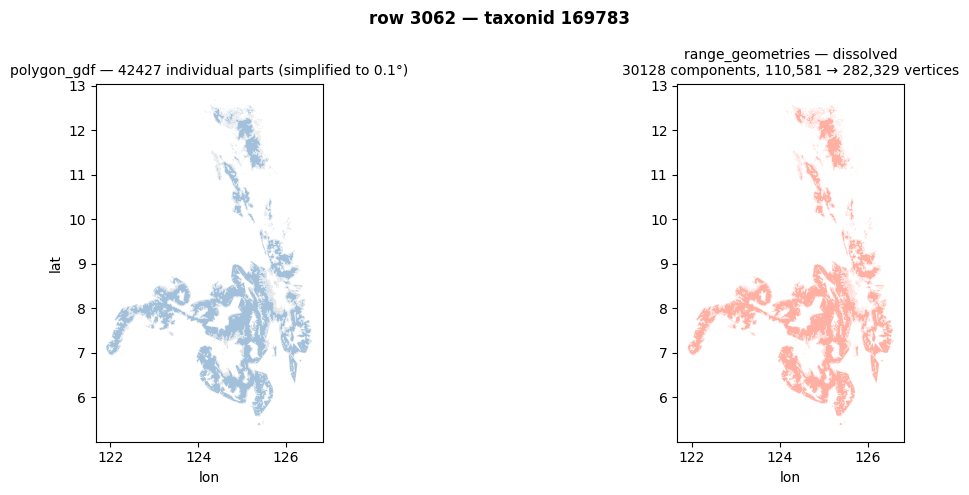

In [42]:
# Inspect a row from range_geometries (by integer index)
INSPECT_ROW = 3062

row = range_geometries.iloc[INSPECT_ROW]
tid = row.taxonid
parts_dissolved = list(row.geometry.geoms) if hasattr(row.geometry, 'geoms') else [row.geometry]
parts_raw = polygon_gdf[polygon_gdf["taxonid"] == tid]

n_vertices_before = _pre_simplify_vertices.get(tid)  # None if not simplified
n_vertices_after  = sum(len(p.exterior.coords) + sum(len(i.coords) for i in p.interiors)
                        for p in parts_dissolved if hasattr(p, "exterior"))

print(f"taxonid:  {tid}")
print(f"presence: {getattr(row, 'spatial_presence', '—')}  |  seasonal: {getattr(row, 'spatial_seasonal', '—')}")
print()
print(f"Individual polygon rows in polygon_gdf (pre-dissolve): {len(parts_raw)}")
print(f"MultiPolygon components after dissolve:                {len(parts_dissolved)}")
print()
if n_vertices_before is not None:
    reduction = 100 * (1 - n_vertices_after / n_vertices_before)
    print(f"Simplification applied at {CENTROID_SIMPLIFY_TOLERANCE}°:")
    print(f"  vertices before: {n_vertices_before:,}")
    print(f"  vertices after:  {n_vertices_after:,}  ({reduction:.0f}% reduction)")
else:
    print(f"No simplification applied (below {CENTROID_SIMPLIFY_THRESHOLD:,}-vertex threshold)")
    print(f"  vertices: {n_vertices_after:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

parts_raw.plot(ax=axes[0], color="steelblue", alpha=0.5, edgecolor="white", linewidth=0.4)
simplified_label = f"simplified to {CENTROID_SIMPLIFY_TOLERANCE}°" if n_vertices_before else "no simplification"
axes[0].set_title(
    f"polygon_gdf — {len(parts_raw)} individual parts ({simplified_label})", fontsize=10)
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")

gpd.GeoDataFrame(geometry=[row.geometry], crs="EPSG:4326").plot(
    ax=axes[1], color="tomato", alpha=0.5, edgecolor="white", linewidth=0.4)
before_str = f"{n_vertices_before:,} → " if n_vertices_before else ""
axes[1].set_title(
    f"range_geometries — dissolved\n"
    f"{len(parts_dissolved)} components, {before_str}{n_vertices_after:,} vertices", fontsize=10)
axes[1].set_xlabel("lon")

fig.suptitle(f"row {INSPECT_ROW} — taxonid {tid}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [46]:
df.shape

(6230, 49)

### Explore taxa that produced several spatial label points

Taxa with several label points: 62


,taxonid,scientific_name,main_common_name,category_iucn,label_points,source,selected_presence,selected_season,components_available,clusters_available,cluster_buffer_km,total_range_area_km2
116,6494,Dermochelys coriacea,Leatherback Turtle,VU,2,range_polygon,Extant,Resident,8,3,200,2.075789e+08
229,11534,Lepidochelys olivacea,Olive Ridley Turtle,VU,2,range_polygon,Extant,Resident,26,3,200,7.973229e+07
101,5671,Crocodylus siamensis,Siamese Crocodile,CR,2,range_polygon,Extant,Resident,848,2,200,1.736119e+06
106,6004,Cyclanorbis elegans,Nubian Flapshell Turtle,CR,2,range_polygon,Extant,Resident,16,2,200,6.581690e+05
3006,163414,Cuora mouhotii,Keeled Box Turtle,EN,2,range_polygon,Extant,Resident,82,2,200,6.249664e+05
255,12774,Manouria emys,Asian Giant Tortoise,CR,2,range_polygon,Extant,Resident,6,2,200,6.074042e+05
246,12152,Litoria raniformis,Green and Gold Frog,VU,2,range_polygon,Extant,Resident,9,2,200,5.687617e+05
454,39430,Geochelone elegans,Indian Star Tortoise,VU,2,range_polygon,Extant,Resident,5,2,200,4.712781e+05
2984,157245,Darevskia praticola,Meadow Lizard,NT,2,range_polygon,Extant,Resident,6,2,200,2.716451e+05
76,3898,Carettochelys insculpta,Pig-nosed Turtle,EN,2,range_polygon,Extant,Resident,60,2,200,2.410143e+05


Exploring taxonid: 6494


,taxonid,scientific_name,main_common_name,category_iucn,centroid_rank,centroid_count,centroid_source,lon,lat,computed_range_component_area_km2,computed_range_area_km2,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence_label,spatial_seasonal_label
122,6494,Dermochelys coriacea,Leatherback Turtle,VU,1,2,range_polygon,-106.837946,-7.310695,1.148722e+08,2.075789e+08,8,3,3,200,0.553391,Extant,Resident
123,6494,Dermochelys coriacea,Leatherback Turtle,VU,2,2,range_polygon,143.976115,7.651478,5.948391e+07,2.075789e+08,8,3,4,200,0.286561,Extant,Resident


,cluster_rank,cluster_area_km2,range_cluster_area_share,cluster_component_count,selected_for_label
0,1,1.148722e+08,0.553391,3,True
1,2,5.948391e+07,0.286561,4,True
2,3,3.322273e+07,0.160049,1,False


,taxonid,raw_polygon_area_km2,spatial_presence_label,spatial_seasonal_label,source_path
27448,6494,5.265866e+07,Extant,Resident,REPTILES_PART1.shp
27442,6494,4.181711e+07,Extant,Resident,REPTILES_PART1.shp
27445,6494,3.577771e+07,Extant,Resident,REPTILES_PART1.shp
27447,6494,3.322273e+07,Extant,Resident,REPTILES_PART1.shp
27441,6494,3.294741e+07,Extant,Resident,REPTILES_PART1.shp
27446,6494,3.294741e+07,Extant,Resident,REPTILES_PART1.shp
27451,6494,1.286864e+07,Extant,Resident,REPTILES_PART1.shp
27444,6494,6.825222e+06,Extant,Resident,REPTILES_PART1.shp
27443,6494,7.460612e+01,Extant,Resident,REPTILES_PART1.shp
27449,6494,2.474913e+01,Extant,Resident,REPTILES_PART1.shp


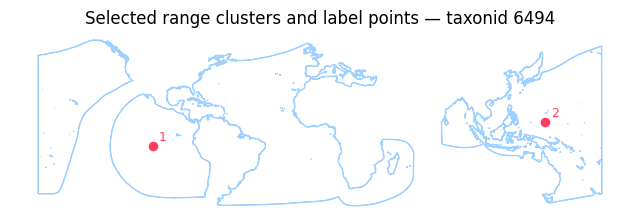

In [44]:
# Set EXPLORE_TAXONID to one taxonid from multi_centroid_summary, or leave None to inspect the first one.
EXPLORE_TAXONID = None
SHOW_EXPLORE_MAP = True

explore_centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence_label", "spatial_seasonal_label",
    "computed_range_area_km2", "computed_range_component_area_km2",
]
missing_centroid_cols = [col for col in explore_centroid_cols if col not in centroids.columns]
if missing_centroid_cols:
    raise RuntimeError(f"Run the spatial centroid cell before this exploration cell. Missing columns: {missing_centroid_cols}")

taxa_for_explore = df.drop(columns=[col for col in explore_centroid_cols if col != "taxonid"], errors="ignore").copy()
taxa_for_explore["taxonid"] = taxa_for_explore["taxonid"].astype(int)
taxa_for_explore = taxa_for_explore.drop_duplicates(subset="taxonid")
explore_df = taxa_for_explore.merge(centroids[explore_centroid_cols], on="taxonid", how="inner")

multi_centroid_summary = (
    explore_df.groupby(["taxonid", "scientific_name", "main_common_name", "category_iucn"], dropna=False)
    .agg(
        label_points=("centroid_rank", "count"),
        source=("centroid_source", first_non_empty),
        selected_presence=("spatial_presence_label", first_non_empty),
        selected_season=("spatial_seasonal_label", first_non_empty),
        components_available=("range_component_count", "max"),
        clusters_available=("range_cluster_count", "max"),
        cluster_buffer_km=("range_cluster_buffer_km", first_non_empty),
        total_range_area_km2=("computed_range_area_km2", "max"),
    )
    .reset_index()
    .query("label_points > 1")
    .sort_values(["label_points", "total_range_area_km2"], ascending=[False, False])
)

print(f"Taxa with several label points: {len(multi_centroid_summary):,}")
display(multi_centroid_summary.head(25))

if multi_centroid_summary.empty:
    print("No taxa with several label points in the current sample.")
else:
    selected_taxonid = int(EXPLORE_TAXONID or multi_centroid_summary.iloc[0].taxonid)
    print(f"Exploring taxonid: {selected_taxonid}")

    selected_points = (
        explore_df[explore_df["taxonid"].astype(int) == selected_taxonid]
        .sort_values("centroid_rank")
        [[
            "taxonid", "scientific_name", "main_common_name", "category_iucn",
            "centroid_rank", "centroid_count", "centroid_source", "lon", "lat",
            "computed_range_component_area_km2", "computed_range_area_km2",
            "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
            "spatial_presence_label", "spatial_seasonal_label",
        ]]
    )
    display(selected_points)

    selected_centroid_geoms = centroids[centroids["taxonid"].astype(int) == selected_taxonid].sort_values("centroid_rank")
    selected_range_geom = range_geometries[range_geometries["taxonid"].astype(int) == selected_taxonid]
    selected_clusters = gpd.GeoDataFrame(columns=["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label", "geometry"], geometry="geometry", crs="EPSG:4326")
    if not selected_range_geom.empty:
        selected_parts = polygon_parts(selected_range_geom.iloc[0].geometry)
        if selected_parts:
            selected_clusters = cluster_range_parts(selected_parts, RANGE_CLUSTER_BUFFER_KM).sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
            selected_clusters["cluster_rank"] = selected_clusters.index + 1
            selected_total_area = selected_clusters["cluster_area_km2"].sum()
            selected_clusters["range_cluster_area_share"] = 0.0
            if selected_total_area > 0:
                selected_clusters["range_cluster_area_share"] = selected_clusters["cluster_area_km2"] / selected_total_area
            selected_clusters["selected_for_label"] = (
                (selected_clusters["cluster_rank"] == 1)
                | (
                    (selected_clusters["cluster_rank"] <= MAX_RANGE_CENTROIDS_PER_SPECIES)
                    & (selected_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
                )
            )
            display(selected_clusters[["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label"]].head(30))
    selected_raw_polygons = polygon_gdf[polygon_gdf["taxonid"].astype(int) == selected_taxonid].copy()
    if not selected_raw_polygons.empty:
        selected_raw_polygons = selected_raw_polygons.copy()
        selected_raw_polygons["raw_polygon_area_km2"] = selected_raw_polygons.to_crs(6933).area / 1e6
        display(
            selected_raw_polygons
            .assign(
                spatial_presence_label=lambda d: d["spatial_presence"].map(presence_label),
                spatial_seasonal_label=lambda d: d["spatial_seasonal"].map(seasonal_label),
            )
            .sort_values("raw_polygon_area_km2", ascending=False)
            [["taxonid", "raw_polygon_area_km2", "spatial_presence_label", "spatial_seasonal_label", "source_path"]]
            .head(30)
        )

    if SHOW_EXPLORE_MAP:
        ax = selected_range_geom.boundary.plot(figsize=(8, 5), color="#4b6fff", linewidth=0.45)
        if not selected_clusters.empty:
            selected_clusters.boundary.plot(ax=ax, color="#9bd0ff", linewidth=1.0)
        selected_centroid_geoms.plot(ax=ax, color="#ff3d5a", markersize=35)
        for row in selected_centroid_geoms.itertuples(index=False):
            ax.annotate(str(row.centroid_rank), (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", color="#ff3d5a", fontsize=9)
        ax.set_title(f"Selected range clusters and label points — taxonid {selected_taxonid}")
        ax.set_axis_off()


### Save checkpoint

In [45]:
# ── Checkpoint 2: after Centroids ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df.to_csv(f"{_ckpt_dir}/ckpt_2_centroids_{RUN_MODE}.csv", index=False)
pd.DataFrame(dropped_log).to_csv(f"{_ckpt_dir}/ckpt_2_centroids_dropped_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 2 saved — Centroids: df.shape={df.shape}, dropped_log={len(dropped_log)} taxa")

Checkpoint 2 saved — Centroids: df.shape=(6230, 49), dropped_log=0 taxa


In [80]:
# ── Restart from checkpoint 2 ──
# Run this cell instead of all cells above to resume from after centroids.
_ckpt_dir = "data/cache/checkpoints"
df = pd.read_csv(f"{_ckpt_dir}/ckpt_2_centroids_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_2_centroids_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 2 (centroids): {df.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 2 (centroids): (6230, 49), dropped_log=0 taxa


---
## 3 · Wikidata SPARQL — IUCN ID → Wikipedia article title

Both modes query Wikidata from IUCN taxon IDs. In sample mode, the batch is simply much smaller.

In [81]:
print("Wikidata language priority:", ", ".join(WIKIPEDIA_LANGUAGE_PRIORITY))

Wikidata language priority: en, de, ja, fr, es, ru, it, zh, pt, pl, nl, uk, ca, sv, cs, fi, ko, tr, no, da, eo


In [82]:
# Wikidata batch fetch
wikidata_taxon_ids = df["taxonid"].drop_duplicates().tolist()
wikidata_map = query_wikidata_batch(wikidata_taxon_ids)

Wikidata batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [89]:
# Name-based fallback: taxa whose IUCN taxon ID isn't linked in Wikidata
# (e.g. Catopuma temminckii stored as Pardofelis temminckii, or missing P627)
WIKIDATA_NAME_CACHE_PATH = f"data/cache/wikidata/name_fallback_{RUN_MODE}.json"

unresolved_ids = list(dict.fromkeys(str(t) for t in wikidata_taxon_ids if str(t) not in wikidata_map))
if unresolved_ids:
    name_fallback = ph.query_wikidata_by_names(unresolved_ids, df, cache_path=WIKIDATA_NAME_CACHE_PATH)
    wikidata_map.update(name_fallback)

ph.configure(wikidata_map=wikidata_map)
print(f"Wikipedia articles found: {len(wikidata_map):,} / {len(wikidata_taxon_ids):,} taxa")
print(f"Raw Wikidata P18 images found before map-image filtering: {sum(1 for item in wikidata_map.values() if item.get('wikidata_image_url')):,}")
pd.Series([item.get("wiki_language") for item in wikidata_map.values()]).value_counts().head(10)

  Wikidata name cache: 409 found + 1 not-found entries loaded from data/cache/wikidata/name_fallback_full_other.json
Wikidata name fallback: 202 unique taxa unresolved
  Pass 1 (P225): resolved 0 / 202 — 202 remaining for per-taxon search
  [1/202] Potamon setiger ... found
  [2/202] Tehuana poglayenorum ... found
  [3/202] Stoliczia tweedei ... found
  [4/202] Geothelphusa yangminshan ... not found
  [5/202] Liotelphusa gagei ... found
  [6/202] Ombrastacoides parvicaudatus ...  [Wikimedia] Retry-After: 32s

  [Pass 4 Wikispecies] 429 — waiting 32s
 not found
  [7/202] Ombrastacoides pulcher ... found
  [8/202] Euastacus yarraensis ... found
  [9/202] Euastacus simplex ... found
  [10/202] Ombrastacoides denisoni ...  [Wikimedia] Retry-After: 27s

  [Pass 3 Wikipedia direct] 429 — waiting 27s
 not found
  [11/202] Ombrastacoides asperrimanus ... found
  [12/202] Ombrastacoides dissitus ... found
  [13/202] Gramastacus insolitus ...  [Wikimedia] Retry-After: 31s

  [Pass 4 Wikispecies]

en    5279
fr     395
nl     261
pt     103
sv      24
zh      22
de      19
uk      12
es       9
bg       8
Name: count, dtype: int64

In [ ]:
# Remove taxa that share a wiki_url: two IUCN taxa resolving to the same
# Wikipedia article is ambiguous. Treated as not found — shown on globe
# without a Wikipedia link, popularity imputed to 1.

# WARNING: NO NEED FOR MAMMALS (3 cases are legit) NOR BIRDS NOR MARINE FISH (no cases)

_url_to_tids = {}
for tid, v in wikidata_map.items():
    url = v.get("wiki_url")
    if url:
        _url_to_tids.setdefault(url, []).append(tid)

_shared = {url: tids for url, tids in _url_to_tids.items() if len(tids) > 1}
_tids_to_remove = [tid for tids in _shared.values() for tid in tids]
for tid in _tids_to_remove:
    del wikidata_map[tid]

ph.configure(wikidata_map=wikidata_map)
ph.log_dropped(dropped_log, {int(t) for t in _tids_to_remove}, set(),
               "shared_wiki_url", "Multiple IUCN taxa resolved to the same Wikipedia article", df)
print(f"Removed {len(_tids_to_remove)} taxa sharing a wiki_url ({len(_shared)} duplicate URLs)")
for url, tids in sorted(_shared.items(), key=lambda x: -len(x[1])):
    names = [df.loc[df["taxonid"].astype(str)==tid, "scientific_name"].iloc[0]
             if (df["taxonid"].astype(str)==tid).any() else tid for tid in tids]
    print(f"  {url}")
    for n in names:
        print(f"    - {n}")

  [shared_wiki_url] 38 taxa dropped: Multiple IUCN taxa resolved to the same Wikipedia article
Removed 38 taxa sharing a wiki_url (2 duplicate URLs)
  https://en.wikipedia.org/wiki/Nancy_(given_name)
    - Glyphoglossus smithi
    - Stumpffia roseifemoralis
    - Tehuana poglayenorum
    - Stoliczia tweedei
    - Ombrastacoides pulcher
    - Euastacus yarraensis
    - Euastacus simplex
    - Ombrastacoides asperrimanus
    - Ombrastacoides dissitus
    - Procambarus vazquezae
    - Rhinophis tricoloratus
    - Leptobrachella khasiorum
    - Leptopalaemon gibbosus
    - Leptopalaemon magelensis
    - Leptopalaemon gudjangah
    - Leptobrachella sabahmontana
    - Leptobrachella marmorata
    - Leptobrachella pallida
    - Chiasmocleis altomontana
    - Chiasmocleis veracruz
    - Craugastor gutschei
    - Gastrotheca turnerorum
    - Gastrotheca yacuri
    - Megophrys feii
    - Boophis nauticus
    - Brachycephalus mirissimus
    - Ischnocnema feioi
    - Ischnocnema parnaso
    - Dend

In [193]:
#df[df.scientific_name.str.contains('viridis')] #silvestris

In [194]:
#wikidata_map['281708504']

In [195]:
# Manual retry — re-run the fallback chain for specific scientific names
# without re-launching the full Wikidata batch fetch above.
# Edit the list below, then run this cell.
MANUAL_RETRY_NAMES = [
    #"Otomys auratus",
    # "Another Species Name",
]

_retry_rows = df[df["scientific_name"].isin(MANUAL_RETRY_NAMES)].drop_duplicates(subset="taxonid")
if _retry_rows.empty:
    print("None of the names found in df — check spelling matches IUCN scientific_name exactly.")
else:
    _retry_ids = _retry_rows["taxonid"].tolist()
    print(f"Retrying {len(_retry_ids)} taxa: {_retry_rows['scientific_name'].tolist()}")
    _retry_result = ph.query_wikidata_by_names(_retry_ids, _retry_rows)
    if _retry_result:
        wikidata_map.update(_retry_result)
        ph.configure(wikidata_map=wikidata_map)
        print(f"Updated wikidata_map — now {len(wikidata_map):,} taxa resolved")
        for tid, entry in _retry_result.items():
            sci = _retry_rows.loc[_retry_rows["taxonid"].astype(str) == str(tid), "scientific_name"].iloc[0] if not _retry_rows.loc[_retry_rows["taxonid"].astype(str) == str(tid)].empty else tid
            print(f"  {sci} → {entry.get('wiki_url') or entry.get('wiki_title') or 'no article'}")
    else:
        print("Still not resolved after retry.")

None of the names found in df — check spelling matches IUCN scientific_name exactly.


In [91]:
wikidata_map

{'3897': {'wikidata_url': 'https://www.wikidata.org/entity/Q192095',
  'wiki_title': 'Loggerhead_sea_turtle',
  'wiki_language': 'en',
  'wiki_project': 'en.wikipedia.org',
  'wiki_url': 'https://en.wikipedia.org/wiki/Loggerhead_sea_turtle',
  'wiki_rank': 0,
  'wikidata_image_url': 'https://commons.wikimedia.org/wiki/Special:FilePath/Loggerhead%20sea%20turtle.jpg'},
 '867': {'wikidata_url': 'https://www.wikidata.org/entity/Q194422',
  'wiki_title': 'Chinese_alligator',
  'wiki_language': 'en',
  'wiki_project': 'en.wikipedia.org',
  'wiki_url': 'https://en.wikipedia.org/wiki/Chinese_alligator',
  'wiki_rank': 0,
  'wikidata_image_url': 'https://commons.wikimedia.org/wiki/Special:FilePath/2011%20China-Alligator%200491.JPG'},
 '11004': {'wikidata_url': 'https://www.wikidata.org/entity/Q305966',
  'wiki_title': 'Natal_hinge-back_tortoise',
  'wiki_language': 'en',
  'wiki_project': 'en.wikipedia.org',
  'wiki_url': 'https://en.wikipedia.org/wiki/Natal_hinge-back_tortoise',
  'wiki_rank':

### Parent species Wikidata fallback

Wikipedia coverage is often at species level even when IUCN assesses a threatened subspecies. To avoid dropping those subspecies just because Wikidata/Wikipedia has no infrarank article, the notebook uses a parent-species lookup only when needed.

The displayed taxon stays the infrarank taxon: IUCN status, name, assessment URL, and spatial point remain tied to the displayed row. Only the article/image/pageviews lookup can be inherited from the parent. Parent IDs are queried only if they are missing from the local Wikidata cache, and the parent is never added as a displayed animal.

Rows using a parent article or pageview signal are marked with `wiki_lookup_source = "parent_species"`. Rows using only a parent image are marked separately with `image_lookup_source = "parent_species"`.


In [92]:
# Attach wiki title and Wikidata P18 image.
# If an infrarank taxon has no Wikipedia article, use its parent species as the
# Wikidata/Wikipedia/pageviews/image lookup source while keeping the displayed
# IUCN taxon and conservation status unchanged.
df["wiki_lookup_taxonid"] = df["taxonid"].astype(int)
df["wiki_lookup_source"] = "self"
attach_wikidata_fields(df, wikidata_map)


In [93]:
df.shape

(6230, 57)

In [94]:
parent_taxonid_numeric = pd.to_numeric(df.get("parent_taxonid"), errors="coerce")
missing_self_wiki = df["wiki_title"].isna() & parent_taxonid_numeric.notna()
parent_wiki_ids = sorted(parent_taxonid_numeric[missing_self_wiki].dropna().astype(int).unique())
parent_wiki_ids_to_query = [taxonid for taxonid in parent_wiki_ids if str(taxonid) not in wikidata_map]
if parent_wiki_ids_to_query:
    parent_wikidata_map = query_wikidata_batch(parent_wiki_ids_to_query)
    wikidata_map.update(parent_wikidata_map)

parent_has_wiki = parent_taxonid_numeric.map(lambda taxonid: bool((wikidata_map.get(str(int(taxonid))) or {}).get("wiki_title")) if pd.notna(taxonid) else False)
parent_wiki_fallback = missing_self_wiki & parent_has_wiki
if parent_wiki_fallback.any():
    df.loc[parent_wiki_fallback, "wiki_lookup_taxonid"] = parent_taxonid_numeric[parent_wiki_fallback].astype(int)
    df.loc[parent_wiki_fallback, "wiki_lookup_source"] = "parent_species"
    attach_wikidata_fields(df, wikidata_map)

missing_wiki_taxa = (
    df[df["wiki_title"].isna()]
    .drop_duplicates(subset="taxonid")
    [["taxonid", "parent_taxonid", "scientific_name", "main_common_name", "category_iucn"]]
    .sort_values("taxonid")
)
df_wiki = df.copy()
print(f"Rows: {len(df_wiki):,} label points from {df_wiki.taxonid.nunique():,} taxa")
print(f"Taxa using parent-species Wikipedia fallback: {df_wiki[df_wiki['wiki_lookup_source'] == 'parent_species'].taxonid.nunique():,}")
print(f"Taxa without any Wikipedia article (will show on globe with no wiki link, popularity=1): {len(missing_wiki_taxa):,}")
display(missing_wiki_taxa.head(20))

Rows: 6,230 label points from 6,168 taxa
Taxa using parent-species Wikipedia fallback: 0
Taxa without any Wikipedia article (will show on globe with no wiki link, popularity=1): 54


,taxonid,parent_taxonid,scientific_name,main_common_name,category_iucn
1779,57538,NaN,Megophrys chuannanensis,Chuanan Short-legged Toad,NT
1833,57726,NaN,Glyphoglossus smithi,NaN,NT
1891,58013,NaN,Stumpffia roseifemoralis,NaN,EN
2732,134543,NaN,Tehuana poglayenorum,NaN,EN
2764,134786,NaN,Stoliczia tweedei,NaN,VU
2769,134815,NaN,Geothelphusa yangminshan,Yangmingshan Crab,EN
2958,153612,NaN,Ombrastacoides parvicaudatus,Short-tailed Rain Crayfish,CR
2959,153622,NaN,Ombrastacoides pulcher,NaN,VU
2960,153639,NaN,Euastacus yarraensis,NaN,VU
2965,153686,NaN,Euastacus simplex,NaN,VU


In [95]:
df_wiki.shape

(6230, 57)

In [201]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url


In [202]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("latebricola")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url
1145,22703513,197499379,2021-02-24T00:00:00.000+00:00,2021,https://www.iucnredlist.org/species/22703513/1...,BirdLife International 2021. Scytalopus latebr...,Scytalopus latebricola,Brown-rumped Tapaculo,NT,Stable,...,10 October 2025,BirdLife International and Handbook of the Bir...,22703513,self,Brown-rumped_tapaculo,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Brown-rumped_tap...,https://www.wikidata.org/entity/Q1270944,https://commons.wikimedia.org/wiki/Special:Fil...


### Save checkpoint

In [96]:
# ── Checkpoint 3: after Wikidata ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df_wiki.to_csv(f"{_ckpt_dir}/ckpt_3_wikidata_{RUN_MODE}.csv", index=False)
pd.DataFrame(dropped_log).to_csv(f"{_ckpt_dir}/ckpt_3_wikidata_dropped_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 3 saved — Wikidata: df_wiki.shape={df_wiki.shape}, dropped_log={len(dropped_log)} taxa")

Checkpoint 3 saved — Wikidata: df_wiki.shape=(6230, 57), dropped_log=38 taxa


In [97]:
# ── Restart from checkpoint 3 ──
# Run this cell instead of all cells above to resume from after wikidata.
_ckpt_dir = "data/cache/checkpoints"
df_wiki = pd.read_csv(f"{_ckpt_dir}/ckpt_3_wikidata_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_3_wikidata_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 3 (wikidata): {df_wiki.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 3 (wikidata): (6230, 57), dropped_log=38 taxa


---
## 4 · Wikimedia Pageviews API — 12-month view count

Endpoint: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/monthly/{start}/{end}`

We use the last 12 completed months and sum the monthly totals.

In [104]:
# Last 12 completed months. Wikimedia's monthly endpoint expects YYYYMMDD.
today = date.today()
current_month_start = date(today.year, today.month, 1)
start_month = date(current_month_start.year - 1, current_month_start.month, 1)
if current_month_start.month == 1:
    end_month = date(current_month_start.year - 1, 12, 1)
else:
    end_month = date(current_month_start.year, current_month_start.month - 1, 1)
START = start_month.strftime("%Y%m01")
END = end_month.strftime("%Y%m01")
PAGEVIEW_MONTHS = (end_month.year - start_month.year) * 12 + end_month.month - start_month.month + 1
ph.set_pageview_window(START, END)
print(f"Pageview window: {START} → {END} inclusive ({PAGEVIEW_MONTHS} monthly buckets)")

# Persistent cache: survives kernel interruptions.
_pv_cache_path = f"data/cache/pageviews/{RUN_MODE}_{START}_{END}.json"
os.makedirs("data/cache/pageviews", exist_ok=True)
if os.path.exists(_pv_cache_path):
    with open(_pv_cache_path) as _f:
        _pv_cache_raw = json.load(_f)
    pageview_map = {tuple(k.split("|||")): v for k, v in _pv_cache_raw.items()}
    print(f"Loaded {len(pageview_map):,} cached pageview results from {_pv_cache_path}")
else:
    pageview_map = {}

article_keys = df_wiki[["wiki_project", "wiki_title"]].dropna(subset=["wiki_title"]).drop_duplicates()
_to_fetch = [(r.wiki_project, r.wiki_title) for r in article_keys.itertuples(index=False)
             if (r.wiki_project, r.wiki_title) not in pageview_map]
print(f"Fetching {len(_to_fetch):,} articles ({len(pageview_map):,} already cached) — agent: {ph.PAGEVIEWS_AGENT}")

for i, key in enumerate(tqdm(_to_fetch, desc="Pageviews")):
    _views = get_pageviews(*key)
    pageview_map[key] = _views
    tqdm.write(f"  {_views:>8,}  {key[1]}")
    time.sleep(SLEEP_PAGEVIEWS)
    if (i + 1) % 25 == 0 or i == len(_to_fetch) - 1:
        with open(_pv_cache_path, "w") as _f:
            json.dump({"|||".join(k): v for k, v in pageview_map.items()}, _f)

df_wiki["popularity"] = df_wiki.apply(
    lambda row: pageview_map.get((row.wiki_project, row.wiki_title), 0), axis=1).astype(int)

Pageview window: 20250601 → 20260501 inclusive (12 monthly buckets)
Loaded 4,750 cached pageview results from data/cache/pageviews/full_other_20250601_20260501.json
Fetching 1,364 articles (4,750 already cached) — agent: user


Pageviews:   0%|          | 0/1364 [00:00<?, ?it/s]

       267  Anolis_agueroi
       282  Anolis_altavelensis
       270  Anolis_altitudinalis
       428  Anolis_bahorucoensis
       929  Anolis_baracoae
       233  Anolis_barahonae
     4,462  Anolis_barbatus
       271  Anolis_barbouri
       150  Anolis_birama
       137  Anolis_breslini
       374  Anolis_brunneus
       185  Anolis_christophei
       176  Anolis_chrysops
       178  Anolis_confusus
       737  Anolis_cooki
       249  Anolis_darlingtoni
       130  Anolis_dolichocephalus
       280  Anolis_ernestwilliamsi
       201  Anolis_etheridgei
       453  Anolis_eugenegrahami
       365  Anolis_fairchildi
       215  Anolis_fowleri
       182  Anolis_fugitivus
       214  Anolis_hendersoni
       136  Anolis_inexpectatus
       190  Anolis_insolitus
       185  Anolis_kahouannensis
       289  Anolis_lividus
       138  Anolis_longitibialis
     1,925  Anolis_luciae
       277  Anolis_marcanoi
       532  Anolis_nelsoni
       341  Anolis_noblei
       233  Anolis_pigmaequ

In [ ]:
# Comparison: human-only vs all-agents pageviews on a sample of 50 taxa
# Fetches all-agents counts for the same window and compares rank ordering.
_SAMPLE_N = 50
_sample_keys = (
    df_wiki[["wiki_project", "wiki_title", "scientific_name"]]
    .drop_duplicates(subset=["wiki_project", "wiki_title"])
    .sample(min(_SAMPLE_N, len(df_wiki.drop_duplicates(subset=["wiki_project", "wiki_title"]))),
            random_state=42)
)

_all_agents_map = {}
_human_url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/desktop/user/{title}/monthly/{start}/{end}"
for row in tqdm(_sample_keys.itertuples(index=False), total=len(_sample_keys), desc="All-agents pageviews"):
    encoded = urllib.parse.quote(row.wiki_title, safe="")
    url = _human_url.format(project=row.wiki_project or "en.wikipedia.org",
                            title=encoded, start=START, end=END)
    for attempt in range(4):
        try:
            r = requests.get(url, headers=ph.wikimedia_headers(), timeout=15)
            if r.status_code == 404:
                _all_agents_map[(row.wiki_project, row.wiki_title)] = 0
                break
            if r.status_code == 429:
                wait = ph.wikimedia_retry_after(r, default=30)
                tqdm.write(f"  429 — waiting {wait}s")
                time.sleep(wait)
                continue
            r.raise_for_status()
            _all_agents_map[(row.wiki_project, row.wiki_title)] = sum(i["views"] for i in r.json().get("items", []))
            break
        except Exception as e:
            tqdm.write(f"  error: {e}")
            _all_agents_map[(row.wiki_project, row.wiki_title)] = 0
            break
    time.sleep(SLEEP_PAGEVIEWS)

# Build comparison dataframe
_cmp = _sample_keys.copy()
_cmp["all_agents"] = _cmp.apply(lambda r: pageview_map.get((r.wiki_project, r.wiki_title), 0), axis=1)
_cmp["all_agents_cmp"] = _cmp.apply(lambda r: _all_agents_map.get((r.wiki_project, r.wiki_title), 0), axis=1)
_cmp = _cmp[_cmp["all_agents"] > 0].copy()
_cmp["rank_all"]   = _cmp["all_agents"].rank(ascending=False).astype(int)
_cmp["rank_human"] = _cmp["all_agents_cmp"].rank(ascending=False).astype(int)
_cmp["rank_delta"] = (_cmp["rank_all"] - _cmp["rank_human"]).abs()
_cmp["bot_share"]  = ((_cmp["all_agents"] - _cmp["all_agents_cmp"]) / _cmp["all_agents"].clip(lower=1) * 100).round(1)

print(f"Sample size: {len(_cmp):,} taxa with >0 all-agents views")
print(f"Spearman rank correlation (all-agents vs human): {_cmp['rank_all'].corr(_cmp['rank_human'], method='spearman'):.4f}")
print(f"Mean absolute rank delta: {_cmp['rank_delta'].mean():.1f}")
print(f"Median bot share: {_cmp['bot_share'].median():.1f}%")
print()
print("Largest rank shifts:")
_cmp.nlargest(10, "rank_delta")[["scientific_name", "all_agents", "all_agents_cmp", "rank_all", "rank_human", "rank_delta", "bot_share"]]

In [108]:
#_cmp.human_only.describe()

In [105]:
# If a subspecies has its own article but no pageviews in the selected window,
# use the parent species article/pageviews when available. This keeps parent calls narrow.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
zero_pageviews_with_parent = df_wiki["popularity"].eq(0) & df_wiki_parent_taxonid.notna()
if zero_pageviews_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[zero_pageviews_with_parent])
    parent_pageviews = {}
    for parent_id in sorted(df_wiki_parent_taxonid[zero_pageviews_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        if not entry.get("wiki_title"):
            continue
        key = (entry.get("wiki_project"), entry.get("wiki_title"))
        if key not in pageview_map:
            pageview_map[key] = get_pageviews(*key)
            if ph.pageview_gave_up:
                tqdm.write("  [pageviews] gave up — stopping parent loop")
                break
            time.sleep(SLEEP_PAGEVIEWS * (2 if ph.pageview_throttled else 1))
        parent_pageviews[parent_id] = pageview_map.get(key, 0)
    parent_popularity = df_wiki_parent_taxonid.map(lambda taxonid: parent_pageviews.get(int(taxonid), 0) if pd.notna(taxonid) else 0)
    parent_pageview_fallback = zero_pageviews_with_parent & (parent_popularity > 0)
    if parent_pageview_fallback.any():
        apply_wikidata_entry_to_mask(df_wiki, parent_pageview_fallback, df_wiki_parent_taxonid, "parent_species")
        df_wiki.loc[parent_pageview_fallback, "popularity"] = parent_popularity[parent_pageview_fallback].astype(int)
        print(f"Parent-species pageview fallback applied: {df_wiki.loc[parent_pageview_fallback, 'taxonid'].nunique():,} taxa")

In [106]:
# Diagnose zero-popularity taxa (redirect titles, 404s, or genuinely no traffic)
zero_pop = df_wiki[df_wiki["popularity"] == 0].drop_duplicates(subset="taxonid")
if not zero_pop.empty:
    print(f"Zero-popularity taxa: {len(zero_pop):,}")
    for _, _r in zero_pop[["scientific_name", "wiki_title", "wiki_language", "wiki_url"]].iterrows():
        print(f"  {_r['scientific_name']} | {_r['wiki_language']} | {_r['wiki_title']} | {_r['wiki_url']}")

# Replace 0 views with 1 so taxa appear on the globe at minimum size rather than being dropped.
_zero_mask = df_wiki["popularity"] == 0
if _zero_mask.any():
    df_wiki.loc[_zero_mask, "popularity"] = 1
    _n_taxa = df_wiki.loc[_zero_mask, "taxonid"].nunique()
    print(f"Zero-popularity imputed to 1: {_zero_mask.sum():,} label points ({_n_taxa:,} taxa)")

Zero-popularity taxa: 98
  Alsophis rijgersmaei | en | Leeward_Island_racer | https://en.wikipedia.org/wiki/Leeward_Island_racer
  Homopholis mulleri | en | Muller's_velvet_gecko | https://en.wikipedia.org/wiki/Muller%27s_velvet_gecko
  Heosemys depressa | en | Arakan_forest_turtle | https://en.wikipedia.org/wiki/Arakan_forest_turtle
  Pangshura tecta | en | Indian_roofed_turtle | https://en.wikipedia.org/wiki/Indian_roofed_turtle
  Beduka koynayensis | en | Beduka_koynayensis | https://en.wikipedia.org/wiki/Beduka_koynayensis
  Boana claresignata | en | Boana_claresignata | https://en.wikipedia.org/wiki/Boana_claresignata
  Boana clepsydra | en | Boana_clepsydra | https://en.wikipedia.org/wiki/Boana_clepsydra
  Litoria daviesae | en | Davies'_tree_frog | https://en.wikipedia.org/wiki/Davies%27_tree_frog
  Duellmanohyla salvadorensis | en | Ptychohyla_salvadorensis | https://en.wikipedia.org/wiki/Ptychohyla_salvadorensis
  Pristimantis carranguerorum | en | Pristimantis_carranguerorum 

In [107]:
df_wiki.sort_values('popularity')[['scientific_name', 'popularity']].head()

,scientific_name,popularity
5358,Leptobrachella ardens,1
6053,Potamonautes ntendekaensis,1
6035,Eleutherodactylus geitonos,1
1274,Pristimantis carranguerorum,1
5212,Leptobrachella kecil,1


### Save checkpoint

In [108]:
# ── Checkpoint 4: after Pageviews ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df_wiki.to_csv(f"{_ckpt_dir}/ckpt_4_pageviews_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 4 saved — Pageviews: df_wiki.shape={df_wiki.shape}")

Checkpoint 4 saved — Pageviews: df_wiki.shape=(6230, 58)


In [109]:
# ── Restart from checkpoint 4 ──
# Run this cell instead of all cells above to resume from after pageviews.
_ckpt_dir = "data/cache/checkpoints"
df_wiki = pd.read_csv(f"{_ckpt_dir}/ckpt_4_pageviews_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_3_wikidata_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 4 (pageviews): {df_wiki.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 4 (pageviews): (6230, 58), dropped_log=38 taxa


### Image fallbacks

In [114]:
# Query Wikipedia thumbnails once per unique article
wikidata_map_like = df_wiki.apply(lambda r: is_probable_range_map_title(
    r["wikidata_image_url"], r.get("scientific_name"), r.get("main_common_name")), axis=1)
excluded_wikidata_image_taxa = df_wiki.loc[wikidata_map_like, "taxonid"].nunique()
if excluded_wikidata_image_taxa:
    for _, _r in df_wiki.loc[wikidata_map_like, ["scientific_name", "wikidata_image_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikidata_image_url']}")
df_wiki.loc[wikidata_map_like, "wikidata_image_url"] = None
print(f"Map-like Wikidata P18 images excluded before thumbnail fallback: {excluded_wikidata_image_taxa:,} taxa")

# Persistent cache: survives kernel interruptions.
_thumb_cache_path = f"data/cache/thumbnails/{RUN_MODE}.json"
os.makedirs("data/cache/thumbnails", exist_ok=True)
if os.path.exists(_thumb_cache_path):
    with open(_thumb_cache_path) as _f:
        _thumb_cache_raw = json.load(_f)
    thumbnail_map = {tuple(k.split("|||")): v for k, v in _thumb_cache_raw.items()}
    print(f"Loaded {len(thumbnail_map):,} cached thumbnail results from {_thumb_cache_path}")
else:
    thumbnail_map = {}

missing_image_articles = df_wiki.loc[df_wiki["wiki_project"].notna() & df_wiki["wiki_title"].notna(), ["wiki_project", "wiki_title"]].drop_duplicates()
_to_fetch = [(r.wiki_project, r.wiki_title) for r in missing_image_articles.itertuples(index=False)
             if (r.wiki_project, r.wiki_title) not in thumbnail_map]
print(f"Wikipedia thumbnail requests: {len(_to_fetch):,} to fetch ({len(thumbnail_map):,} already cached)")
for i, key in enumerate(tqdm(_to_fetch, desc="Wikipedia thumbnails")):
    thumbnail_map[key] = get_wikipedia_thumbnail(key[0], key[1])
    time.sleep(SLEEP_THUMBNAILS)
    if (i + 1) % 25 == 0 or i == len(_to_fetch) - 1:
        with open(_thumb_cache_path, "w") as _f:
            json.dump({"|||".join(k): v for k, v in thumbnail_map.items()}, _f)

df_wiki["wikipedia_thumbnail_url"] = df_wiki.apply(lambda row: thumbnail_map.get((row.wiki_project, row.wiki_title)), axis=1)
wikipedia_map_like = df_wiki.apply(lambda r: is_probable_range_map_title(
    r["wikipedia_thumbnail_url"], r.get("scientific_name"), r.get("main_common_name")), axis=1)
excluded_wikipedia_image_taxa = df_wiki.loc[wikipedia_map_like, "taxonid"].nunique()
if excluded_wikipedia_image_taxa:
    for _, _r in df_wiki.loc[wikipedia_map_like, ["scientific_name", "wikipedia_thumbnail_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikipedia_thumbnail_url']}")
df_wiki.loc[wikipedia_map_like, "wikipedia_thumbnail_url"] = None
print(f"Map-like Wikipedia thumbnail images excluded: {excluded_wikipedia_image_taxa:,} taxa")

Map-like Wikidata P18 images excluded before thumbnail fallback: 0 taxa
Wikipedia thumbnail requests: 6,114 unique articles (all taxa)


Wikipedia thumbnails:   0%|          | 0/6114 [00:00<?, ?it/s]

  [Wikimedia] Retry-After: 32s
  [thumbnail] 429 — waiting 32s for https://api.wikimedia.org/core/v1/wikipedia/en/page/Alsodes_montanus/bare


KeyboardInterrupt: 

In [ ]:
# Then query Commons once per unique taxon still without an image
# and map results back to all duplicate label points.
_commons_cache_path = f"data/cache/commons/{RUN_MODE}.json"
os.makedirs("data/cache/commons", exist_ok=True)
if os.path.exists(_commons_cache_path):
    with open(_commons_cache_path) as _f:
        commons_map = json.load(_f)
    print(f"Loaded {len(commons_map):,} cached Commons results from {_commons_cache_path}")
else:
    commons_map = {}

missing_thumbnail_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna(),
    ["taxonid", "scientific_name", "main_common_name"]
].drop_duplicates(subset="taxonid")
_to_fetch = [row for row in missing_thumbnail_taxa.itertuples(index=False)
             if str(row.taxonid) not in commons_map]
print(f"Commons image search: {len(_to_fetch):,} to fetch ({len(commons_map):,} already cached)")
for i, row in enumerate(tqdm(_to_fetch, desc="Commons images")):
    _res = search_commons_image(row.scientific_name, row.main_common_name)
    commons_map[str(row.taxonid)] = _res
    if _res and _res.get("commons_image_url"):
        tqdm.write(f"  [Commons] found for {row.scientific_name}: {_res.get('commons_image_url')}")
    time.sleep(SLEEP_WIKI)
    if (i + 1) % 25 == 0 or i == len(_to_fetch) - 1:
        with open(_commons_cache_path, "w") as _f:
            json.dump(commons_map, _f)

commons_fields = [
    "commons_image_url", "commons_image_page_url", "commons_image_title", "commons_image_author",
    "commons_image_license", "commons_image_license_url", "commons_image_credit",
    "commons_image_search_source", "commons_image_search_term",
]
for field in commons_fields:
    df_wiki[field] = df_wiki["taxonid"].astype(str).map(lambda taxonid: (commons_map.get(taxonid) or {}).get(field))

In [ ]:
# Examples of commons images
from IPython.display import HTML

_found = [(tid, v) for tid, v in commons_map.items() if v and v.get("commons_image_url")]
print(f"Commons images found: {len(_found):,} / {len(commons_map):,} taxa searched")

_sample = _found[:12]
_cells = []
for tid, v in _sample:
    _rows = df_wiki[df_wiki["taxonid"].astype(str) == str(tid)]
    name = _rows["scientific_name"].iloc[0] if not _rows.empty else str(tid)
    wiki_url = _rows["wiki_url"].iloc[0] if not _rows.empty and "wiki_url" in _rows.columns else ""
    img = v.get("commons_image_url") or ""
    credit = (v.get("commons_image_credit") or v.get("commons_image_author") or "")[:40]
    lic = v.get("commons_image_license") or ""
    page = v.get("commons_image_page_url") or img
    name_html = ("<a href='" + str(wiki_url) + "' target='_blank'><b>" + str(name) + "</b></a>") if wiki_url else ("<b>" + str(name) + "</b>")
    _cells.append(
        "<td style='padding:6px;vertical-align:top;font-size:11px;max-width:160px'>"
        + "<a href='" + page + "' target='_blank'>"
        + "<img src='" + img + "' style='max-width:150px;max-height:110px;border-radius:4px'></a><br>"
        + name_html + "<br>"
        + "<span style='color:#888'>" + credit + "</span><br>"
        + "<span style='color:#aaa'>" + lic + "</span></td>"
    )

rows_html = ""
for i, c in enumerate(_cells):
    if i % 4 == 0:
        rows_html += "<tr>"
    rows_html += c
    if (i + 1) % 4 == 0 or i + 1 == len(_cells):
        rows_html += "</tr>"

display(HTML("<table>" + rows_html + "</table>"))

In [ ]:
# Debug a single Commons image search call
# Change the name below to inspect any species.
_DEBUG_SCI = "Goniopora tantillus"
_DEBUG_COMMON = ""  # optional common name

_result = search_commons_image(_DEBUG_SCI, _DEBUG_COMMON)
print(f"Result for {_DEBUG_SCI!r}:")
if _result:
    for k, v in _result.items():
        print(f"  {k}: {v}")
    _img = _result.get("commons_image_url")
    if _img:
        _page = _result.get("commons_image_page_url") or _img
        display(HTML(
            "<a href='" + _page + "' target='_blank'>"
            + "<img src='" + _img + "' style='max-height:240px;border-radius:6px;margin-top:8px'></a>"
        ))
else:
    print("  No result found.")

In [ ]:
# Ensure optional image columns exist (skipped fetch cells leave them absent)
for _col in ["wikipedia_thumbnail_url", "wikidata_image_url", "commons_image_url"]:
    if _col not in df_wiki.columns:
        df_wiki[_col] = None

df_wiki["image_url"] = df_wiki["wikipedia_thumbnail_url"].fillna(df_wiki["wikidata_image_url"]).fillna(df_wiki["commons_image_url"])
df_wiki["image_source"] = None
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].notna(), "image_source"] = "Wikipedia thumbnail"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].notna(), "image_source"] = "Wikidata P18"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].isna() & df_wiki["commons_image_url"].notna(), "image_source"] = "Wikimedia Commons search"
df_wiki["image_lookup_taxonid"] = pd.to_numeric(df_wiki["wiki_lookup_taxonid"], errors="coerce")
df_wiki["image_lookup_source"] = df_wiki["wiki_lookup_source"]

# If every direct image fallback failed for an infrarank taxon, try the parent species image
# without changing the displayed taxon identity. Only image-missing rows trigger this work.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
missing_image_with_parent = df_wiki["image_url"].isna() & df_wiki_parent_taxonid.notna()
if missing_image_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[missing_image_with_parent])
    parent_image_map = {}
    for parent_id in sorted(df_wiki_parent_taxonid[missing_image_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        parent_wikidata_image = entry.get("wikidata_image_url")
        if is_probable_range_map_title(parent_wikidata_image, row.get("scientific_name"), row.get("main_common_name")):
            parent_wikidata_image = None
        parent_thumbnail = None
        if not parent_wikidata_image and entry.get("wiki_project") and entry.get("wiki_title"):
            parent_thumbnail = get_wikipedia_thumbnail(entry.get("wiki_project"), entry.get("wiki_title"))
            time.sleep(SLEEP_WIKI)
            if is_probable_range_map_title(parent_thumbnail, row.get("scientific_name"), row.get("main_common_name")):
                parent_thumbnail = None
        parent_image_map[parent_id] = {
            "wikidata_image_url": parent_wikidata_image,
            "wikipedia_thumbnail_url": parent_thumbnail,
        }

    parent_image_url = df_wiki_parent_taxonid.map(
        lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url")
        or (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url")
    )
    parent_image_fallback = missing_image_with_parent & parent_image_url.notna()
    if parent_image_fallback.any():
        parent_wikidata_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url"))
        parent_thumbnail_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url"))
        df_wiki.loc[parent_image_fallback, "wikidata_image_url"] = parent_wikidata_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "wikipedia_thumbnail_url"] = parent_thumbnail_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_url"] = parent_image_url[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_lookup_taxonid"] = df_wiki_parent_taxonid[parent_image_fallback].astype(int)
        df_wiki.loc[parent_image_fallback, "image_lookup_source"] = "parent_species"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.notna(), "image_source"] = "Parent species Wikidata P18"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.isna() & parent_thumbnail_values.notna(), "image_source"] = "Parent species Wikipedia thumbnail"
        print(f"Parent-species image fallback applied: {df_wiki.loc[parent_image_fallback, 'taxonid'].nunique():,} taxa")

image_taxa = df_wiki.drop_duplicates(subset="taxonid")
print(f"Commons fallback images found: {image_taxa.commons_image_url.notna().sum():,} taxa")

Commons images:   0%|          | 0/268 [00:00<?, ?it/s]

Commons fallback images found: 16 taxa


In [ ]:
# Convert TIFF Wikimedia URLs to JPEG thumbnails (not displayable natively in browsers)
if "image_url" not in df_wiki.columns:
    print("Skipped: image_url column not present — run image assembly cells first")
else:
    tiff_mask = df_wiki["image_url"].notna() & df_wiki["image_url"].str.lower().str.endswith((".tif", ".tiff"))
    if tiff_mask.any():
        df_wiki.loc[tiff_mask, "image_url"] = df_wiki.loc[tiff_mask, "image_url"].map(ph.wikimedia_tiff_to_thumbnail)
        print(f"TIFF → thumbnail conversion: {tiff_mask.sum():,} image URLs converted")

TIFF → thumbnail conversion: 7 image URLs converted
Images found: 1,962 / 2,214 taxa (2,116 label points)


In [242]:
# Taxa with 2 images (Wikipedia thumbnail + distinct Wikidata P18 → slideshow in globe)
_two_images = df_wiki.drop_duplicates(subset="taxonid").copy()
_two_images = _two_images[
    _two_images["wikipedia_thumbnail_url"].notna() &
    _two_images["wikidata_image_url"].notna()
].copy()
_two_images["_fn_wiki"] = _two_images["wikipedia_thumbnail_url"].map(ph.wikimedia_filename)
_two_images["_fn_wikidata"] = _two_images["wikidata_image_url"].map(ph.wikimedia_filename)
_two_images = _two_images[_two_images["_fn_wiki"] != _two_images["_fn_wikidata"]]
_two_images = _two_images[["scientific_name", "main_common_name", "category_iucn",
                            "wikipedia_thumbnail_url", "wikidata_image_url"]].copy()
print(f"Taxa with both a Wikipedia thumbnail and a genuinely distinct Wikidata P18 image: {len(_two_images):,}")
_two_images

Taxa with both a Wikipedia thumbnail and a genuinely distinct Wikidata P18 image: 78


,scientific_name,main_common_name,category_iucn,wikipedia_thumbnail_url,wikidata_image_url
0,Rhea americana,Greater Rhea,NT,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
2,Apteryx owenii,Little Spotted Kiwi,NT,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
4,Apteryx haastii,Great Spotted Kiwi,VU,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
6,Tinamus solitarius,Solitary Tinamou,NT,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
10,Crypturellus boucardi,Slaty-breasted Tinamou,VU,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
...,...,...,...,...,...
1875,Alcedo euryzona,Javan Blue-banded Kingfisher,CR,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
2057,Rhynchostruthus percivali,Arabian Grosbeak,NT,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
2060,Polyplectron katsumatae,Hainan Peacock-Pheasant,EN,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
2246,Orthotomus chaktomuk,Cambodian Tailorbird,NT,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...


In [243]:
# Visual check: show Wikipedia thumbnail vs Wikidata P18 side by side for a sample
# Confirms that the filename-based deduplication above worked — all pairs should look different.
from IPython.display import display, HTML

_sample = _two_images.head(10)
rows_html = []
for _, r in _sample.iterrows():
    name = r["scientific_name"] or ""
    wiki_url = r["wikipedia_thumbnail_url"] or ""
    wikidata_url = r["wikidata_image_url"] or ""
    fn_wiki = ph.wikimedia_filename(wiki_url)
    fn_wikidata = ph.wikimedia_filename(wikidata_url)
    same = fn_wiki == fn_wikidata
    label = "\u26a0 same filename" if same else "\u2713 different"
    color = "red" if same else "green"
    row = (
        '<tr>'
        '<td style="padding:6px;font-size:12px;vertical-align:top">'
        + name + '<br><span style="font-size:10px;color:' + color + '">' + label + '</span></td>'
        '<td style="padding:6px"><img src="' + wiki_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wiki + '</span></td>'
        '<td style="padding:6px"><img src="' + wikidata_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wikidata + '</span></td>'
        '</tr>'
    )
    rows_html.append(row)

display(HTML('<table border="1" cellspacing="0">' + ''.join(rows_html) + '</table>'))

Rhea americana✓ different,nandu rhea americana tierpark hellabrunn-1.jpg,grupo de emas - rhea americana.jpg
Apteryx owenii✓ different,20180703 kiwi-sonya9 959 dxo.jpg,apteryx owenii 0.jpg
Apteryx haastii✓ different,apteryxhaastiikeulemans.jpg,apteryx haastii.jpg
Tinamus solitarius✓ different,"tinamus solitarius -intervales state park, sao paulo, brazil-8.jpg",tinamus solitarius - miguel - 569308105.jpeg
Crypturellus boucardi✓ different,crypturellus boucardi 176516122.jpg,crypturellus boucardi (cropped).jpg
Penelope ortoni✓ different,penelope ortoni 104824422.jpg,orton's guan (penelope ortoni).jpg
Penelope perspicax✓ different,cauca guan.jpg,penelope perspicax pava caucana cauca guan.jpg
Penelope pileata✓ different,penelope pileata 444168961.jpg,penelope pileata 1849.jpg
Pipile jacutinga✓ different,black-fronted piping guan - shreeram m v - iguazu argentina.jpg,aburria jacutinga -parque das aves-8.jpg
Oreophasis derbianus✓ different,"horned guan, st louis zoo.jpg",horned guan.jpg


In [244]:
# Cases where Wikipedia thumbnail and Wikidata P18 refer to the same file (suppressed in slideshow)
from IPython.display import display, HTML

_same_images = df_wiki.drop_duplicates(subset="taxonid").copy()
_same_images = _same_images[
    _same_images["wikipedia_thumbnail_url"].notna() &
    _same_images["wikidata_image_url"].notna() &
    _same_images.apply(lambda r: ph.wikimedia_filename(r["wikipedia_thumbnail_url"]) == ph.wikimedia_filename(r["wikidata_image_url"]), axis=1)
][["scientific_name", "wikipedia_thumbnail_url", "wikidata_image_url"]].copy()
print(f"Same-file pairs (wikidata_image_url will be cleared in image assembly): {len(_same_images):,}")

rows_html = []
for _, r in _same_images.head(10).iterrows():
    name = r["scientific_name"] or ""
    wiki_url = r["wikipedia_thumbnail_url"] or ""
    wikidata_url = r["wikidata_image_url"] or ""
    fn_wiki = ph.wikimedia_filename(wiki_url)
    fn_wikidata = ph.wikimedia_filename(wikidata_url)
    row = (
        '<tr>'
        '<td style="padding:6px;font-size:12px;vertical-align:top">' + name + '<br>'
        '<span style="font-size:10px;color:orange">⚠ same file</span></td>'
        '<td style="padding:6px"><img src="' + wiki_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wiki + '</span></td>'
        '<td style="padding:6px"><img src="' + wikidata_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wikidata + '</span></td>'
        '</tr>'
    )
    rows_html.append(row)

display(HTML('<table border="1" cellspacing="0">' + ''.join(rows_html) + '</table>'))

Same-file pairs (wikidata_image_url will be cleared in image assembly): 77


Apteryx australis⚠ same file,tokoeka.jpg,tokoeka.jpg
Tinamus tao⚠ same file,tao001.jpg,tao001.jpg
Tinamus osgoodi⚠ same file,tinamus osgoodi imported from inaturalist photo 70265010 on 10 april 2021.jpg,tinamus osgoodi imported from inaturalist photo 70265010 on 10 april 2021.jpg
Tinamus guttatus⚠ same file,tinamus guttatus.jpg,tinamus guttatus.jpg
Crypturellus transfasciatus⚠ same file,crypturustransfasciatussmit.jpg,crypturustransfasciatussmit.jpg
Crypturellus noctivagus⚠ same file,crypturellus noctivagus.jpg,crypturellus noctivagus.jpg
Nothoprocta taczanowskii⚠ same file,nothoproctataczanowskiismit.jpg,nothoproctataczanowskiismit.jpg
Nothura minor⚠ same file,nothura minor.jpg,nothura minor.jpg
Taoniscus nanus⚠ same file,taoniscus.jpg,taoniscus.jpg
Ortalis erythroptera⚠ same file,rufous-headed chachalaca.jpg,rufous-headed chachalaca.jpg


In [245]:
# Clear wikidata_image_url when it refers to the same file as image_url (avoids false slideshow in globe)
def _same_wikimedia_file(url_a, url_b):
    return bool(url_a and url_b and ph.wikimedia_filename(url_a) == ph.wikimedia_filename(url_b))

_same_mask = df_wiki.apply(
    lambda r: _same_wikimedia_file(r.get("image_url"), r.get("wikidata_image_url"))
              or _same_wikimedia_file(r.get("wikipedia_thumbnail_url"), r.get("wikidata_image_url")), axis=1)
if _same_mask.any():
    df_wiki.loc[_same_mask, "wikidata_image_url"] = None
    print(f"Cleared {_same_mask.sum():,} wikidata_image_url entries that matched image_url (same file)")

Cleared 2,001 wikidata_image_url entries that matched image_url (same file)


In [246]:
# iNaturalist image fallback
# For taxa still missing an image after Wikidata, Wikipedia, Commons and parent-species fallbacks.
_inat_cache_path = f"data/cache/inaturalist/{RUN_MODE}.json"
os.makedirs("data/cache/inaturalist", exist_ok=True)
if os.path.exists(_inat_cache_path):
    with open(_inat_cache_path) as _f:
        inat_map = json.load(_f)
    print(f"Loaded {len(inat_map):,} cached iNaturalist results from {_inat_cache_path}")
else:
    inat_map = {}

missing_image_taxa = df_wiki.loc[
    df_wiki["image_url"].isna()
].drop_duplicates(subset="taxonid")[["taxonid", "scientific_name", "main_common_name"]]
_to_fetch_inat = [row for row in missing_image_taxa.itertuples(index=False)
                  if str(row.taxonid) not in inat_map]
print(f"iNaturalist image search: {len(_to_fetch_inat):,} to fetch ({len(inat_map):,} already cached)")
for i, row in enumerate(tqdm(_to_fetch_inat, desc="iNaturalist")):
    image_url, attribution, license_code, inat_url = ph.search_inaturalist_image(row.scientific_name)
    inat_map[str(row.taxonid)] = {"image_url": image_url, "attribution": attribution,
                                   "license_code": license_code, "inat_url": inat_url} if image_url else None
    time.sleep(SLEEP_WIKI)
    if (i + 1) % 25 == 0 or i == len(_to_fetch_inat) - 1:
        with open(_inat_cache_path, "w") as _f:
            json.dump(inat_map, _f)

if inat_map:
    mask = df_wiki["image_url"].isna() & df_wiki["taxonid"].astype(str).isin(
        {k for k, v in inat_map.items() if v})
    df_wiki.loc[mask, "image_url"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (inat_map.get(t) or {}).get("image_url"))
    df_wiki.loc[mask, "image_source"] = "iNaturalist"
    df_wiki.loc[mask, "commons_image_credit"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (inat_map.get(t) or {}).get("attribution"))
    df_wiki.loc[mask, "commons_image_page_url"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (inat_map.get(t) or {}).get("inat_url"))
    _n_found = mask.sum()
    print(f"iNaturalist: {_n_found:,} label points updated ({sum(1 for v in inat_map.values() if v):,} unique taxa found)")
    print()
    for tid, info in sorted((k, v) for k, v in inat_map.items() if v):
        rows = missing_image_taxa.loc[missing_image_taxa["taxonid"].astype(str) == tid]
        name = rows["scientific_name"].iloc[0] if not rows.empty else tid
        print(f"  {name} | license: {info['license_code']} | {info['image_url']}")
else:
    print("iNaturalist: no additional images found")

iNaturalist image search: 252 taxa still without image


iNaturalist:   0%|          | 0/252 [00:00<?, ?it/s]

iNaturalist: 177 label points updated (173 unique taxa)

  Thamnophilus shumbae | license: cc-by-nc-nd | https://inaturalist-open-data.s3.amazonaws.com/photos/58732381/medium.jpg
  Campylorhamphus multostriatus | license: all rights reserved | https://static.inaturalist.org/photos/254959418/medium.jpg
  Cinclodes maculirostris | license: cc-by-nc | https://inaturalist-open-data.s3.amazonaws.com/photos/597327798/medium.jpg
  Pachycephala feminina | license: cc-by-nc | https://inaturalist-open-data.s3.amazonaws.com/photos/457213459/medium.jpeg
  Edolisoma pygmaeum | license: cc-by-nc | https://inaturalist-open-data.s3.amazonaws.com/photos/541763481/medium.jpg
  Edolisoma rostratum | license: all rights reserved | https://static.inaturalist.org/photos/217062773/medium.jpg
  Lamprolia klinesmithi | license: cc-by-nc | https://inaturalist-open-data.s3.amazonaws.com/photos/441525269/medium.jpg
  Rhipidura rufilateralis | license: cc-by | https://inaturalist-open-data.s3.amazonaws.com/photos/

In [ ]:
df_wiki.image_source.value_counts()

### Distribution plots

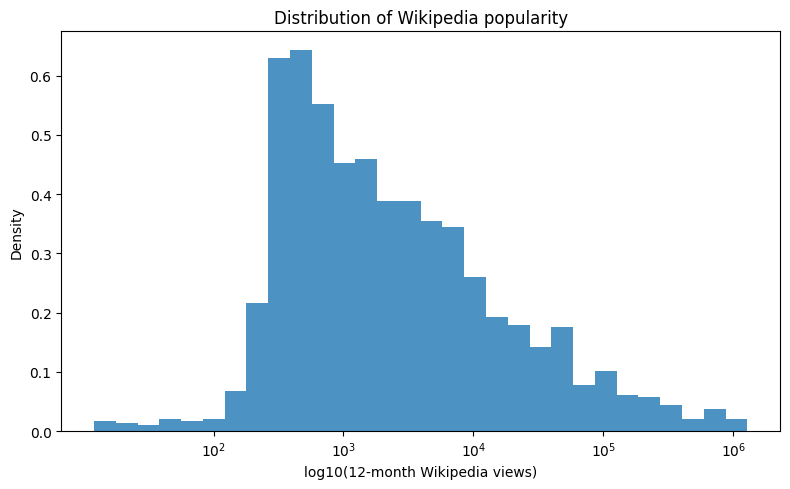

In [134]:

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

log_views = np.log10(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    log_views,
    bins=30,
    density=True,
    alpha=0.8,
)

ax.set_xlabel("log10(12-month Wikipedia views)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Wikipedia popularity")

# nicer tick labels
ticks = [2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f"$10^{t}$" for t in ticks])

plt.tight_layout()
plt.show()

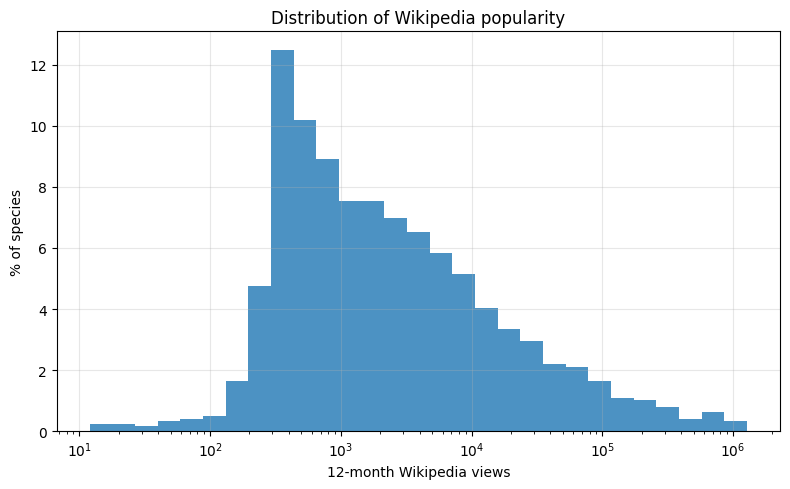

In [135]:

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

bins = np.logspace(
    np.log10(popularity.min()),
    np.log10(popularity.max()),
    30
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    popularity,
    bins=bins,
    weights=np.full(len(popularity), 100 / len(popularity)),
    alpha=0.8,
)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("% of species")
ax.set_title("Distribution of Wikipedia popularity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

count    1.764000e+03
mean     2.358139e+04
std      9.511456e+04
min      1.200000e+01
50%      1.648000e+03
75%      7.554000e+03
90%      3.739050e+04
95%      1.015370e+05
99%      5.550869e+05
max      1.283663e+06
Name: popularity, dtype: float64


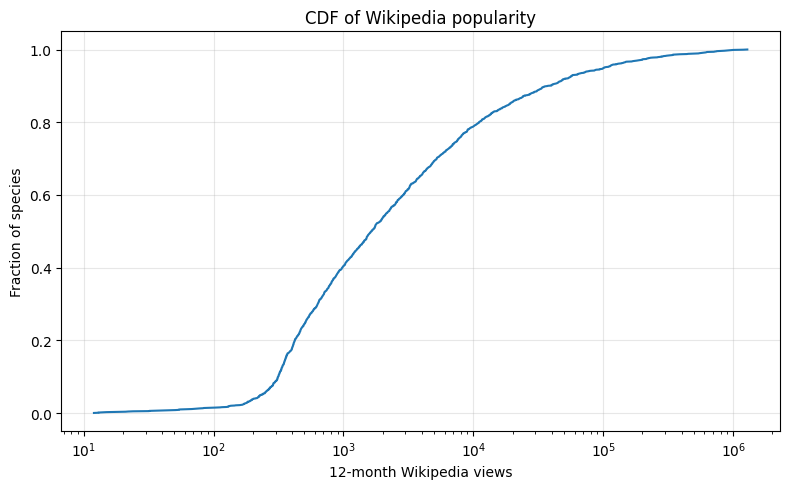

In [136]:

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
    .sort_values()
)

y = np.arange(1, len(popularity) + 1) / len(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(popularity, y)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("Fraction of species")
ax.set_title("CDF of Wikipedia popularity")

ax.grid(alpha=0.3)

print(popularity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.tight_layout()
plt.show()

---
## 5 · Label selection & GeoJSON export

In [249]:
# Label: prefer main_common_name, fall back to scientific_name, then IUCN taxon ID.
common_label = df_wiki["main_common_name"].notna() & (df_wiki["main_common_name"] != "")
scientific_label = df_wiki["scientific_name"].notna() & (df_wiki["scientific_name"] != "")
df_wiki["label"] = "IUCN taxon " + df_wiki["taxonid"].astype(str)
df_wiki.loc[scientific_label, "label"] = df_wiki.loc[scientific_label, "scientific_name"]
df_wiki.loc[common_label, "label"] = df_wiki.loc[common_label, "main_common_name"].map(ph.title_fix_possessive)

# Disambiguation: if two taxa share the same common name when hyphens are stripped,
# append (scientific_name) to both. Hyphens are stripped only for comparison — the
# displayed label keeps them.
_label_key = df_wiki["label"].str.replace("-", "", regex=False).str.casefold()
_dup_mask = _label_key.isin(_label_key[_label_key.duplicated(keep=False)].unique())
if _dup_mask.any():
    df_wiki.loc[_dup_mask, "label"] = (
        df_wiki.loc[_dup_mask, "label"]
        + " (" + df_wiki.loc[_dup_mask, "scientific_name"].fillna("").astype(str) + ")"
    )
    print(f"Disambiguation: {df_wiki.loc[_dup_mask, 'taxonid'].nunique():,} taxa had scientific name appended")

print(f"Final taxon count: {df_wiki.taxonid.nunique():,}")
print(f"Final points count: {len(df_wiki):,}")

Final taxon count: 2,214
Final points count: 2,373


In [ ]:
# Ensure Commons columns exist if the Commons fallback cell was skipped
for _col in ['commons_image_url', 'commons_image_page_url', 'commons_image_title', 'commons_image_author', 'commons_image_license', 'commons_image_license_url', 'commons_image_credit', 'commons_image_search_source', 'commons_image_search_term']:
    if _col not in df_wiki.columns:
        df_wiki[_col] = None

# Build lightweight centroid GeoJSON used by the browser
features = []
required_geojson_cols = {"lon", "lat"}
missing_geojson_cols = required_geojson_cols - set(df_wiki.columns)
if missing_geojson_cols:
    raise RuntimeError(f"Missing centroid coordinate columns before GeoJSON export: {sorted(missing_geojson_cols)}. Rerun the spatial centroid merge cell before exporting.")
for _, row in df_wiki.iterrows():
    lon = clean_json_value(row["lon"])
    lat = clean_json_value(row["lat"])
    if lon is None or lat is None:
        continue
    props = feature_properties(row)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lon), 4), round(float(lat), 4)]
        },
        "properties": props
    })

geojson = {"type": "FeatureCollection", "features": features}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in features if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Written: {OUTPUT_PATH} — {unique_taxa:,} taxa, {len(features):,} features, {size_mb:.1f} MB")
print(f"Run the merge cell to combine all per-mode files into {MERGED_OUTPUT_PATH}")

Written: data/processed/animals_full_birds.geojson — 2,214 taxa, 2,373 features, 7.1 MB
Run the merge cell to combine all per-mode files into animals.geojson


In [251]:
# Dropped animals summary
if dropped_log:
    dropped_df = pd.DataFrame(dropped_log).drop_duplicates(subset="taxonid", keep="first")
    print(f"Total dropped taxa: {len(dropped_df):,}")
    print(dropped_df.groupby('drop_stage')['taxonid'].count().to_string())
else:
    print("No dropped taxa recorded")

No dropped taxa recorded


### Merge result files

Combines all `animals_{mode}.geojson` files from `data/processed/` into the single `animals.geojson` file loaded by the globe.

In [73]:
_merge_prefix = "sample" if RUN_MODE.startswith("sample_") else "full"
per_mode_files = sorted(glob.glob(f"data/processed/animals_{_merge_prefix}_*.geojson"))
if not per_mode_files:
    raise RuntimeError(f"No animals_{_merge_prefix}_*.geojson files found in data/processed/. Run the export cell for at least one {_merge_prefix} mode.")

all_features = []
for path in per_mode_files:
    with open(path, encoding="utf-8") as f:
        gj = json.load(f)
    mode_features = gj.get("features", [])
    all_features.extend(mode_features)
    print(f"  {os.path.basename(path)}: {len(mode_features):,} features")

# Deduplicate by (taxonid, centroid_rank): keep the feature with the most non-null properties.
def _non_null_count(feat):
    return sum(1 for v in (feat.get("properties") or {}).values() if v is not None)

_seen = {}
for feat in all_features:
    _p = feat.get("properties") or {}
    _key = (_p.get("taxonid"), _p.get("centroid_rank", 1))
    if _key not in _seen or _non_null_count(feat) > _non_null_count(_seen[_key]):
        _seen[_key] = feat

_deduped = list(_seen.values())
if len(_deduped) < len(all_features):
    print(f"Deduplication: removed {len(all_features) - len(_deduped):,} duplicate (taxonid, centroid_rank) pairs")

merged = {"type": "FeatureCollection", "features": _deduped}
with open(MERGED_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(merged, f, ensure_ascii=False)

size_mb = os.path.getsize(MERGED_OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in _deduped if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Merged {len(per_mode_files)} {_merge_prefix} files → {MERGED_OUTPUT_PATH}: {unique_taxa:,} taxa, {len(_deduped):,} features, {size_mb:.1f} MB")

  animals_full_birds.geojson: 2,373 features
  animals_full_mammals.geojson: 1,838 features
Merged 2 full files → animals.geojson: 3,978 taxa, 4,211 features, 12.3 MB


### Sanity checks

Load `animals.geojson` and search any species by name.

In [74]:
ANIMALS_PATH = "/Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson"
SEARCH_NAME = "Guam Kingfisher"  # common name, scientific name, or label

with open(ANIMALS_PATH, encoding="utf-8") as f:
    _gj = json.load(f)

records = []
for feat in _gj["features"]:
    props = dict(feat.get("properties") or {})
    coords = (feat.get("geometry") or {}).get("coordinates") or [None, None]
    props["lon"] = coords[0] if len(coords) > 0 else None
    props["lat"] = coords[1] if len(coords) > 1 else None
    records.append(props)

df_geojson = pd.DataFrame(records)
print(f"Loaded: {len(df_geojson):,} points from {df_geojson['taxonid'].nunique():,} taxa ({ANIMALS_PATH})")

_q = SEARCH_NAME.casefold()
_hits = df_geojson[
    df_geojson.get("label", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("main_common_name", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("scientific_name", pd.Series(dtype=str)).str.casefold().eq(_q)
]

if _hits.empty:
    print(f"'{SEARCH_NAME}' not found.")
else:
    _cols = [c for c in ["taxonid", "label", "scientific_name", "category_iucn", "taxon_group",
             "centroid_rank", "popularity", "image_source", "image_url", "wiki_url", "lat", "lon"] if c in _hits.columns]
    _url_cols = [c for c in _hits.columns if "url" in c.lower() or "link" in c.lower()]
    _display_cols = _cols + [c for c in _url_cols if c not in _cols]
    with pd.option_context("display.max_colwidth", 160):
        display(_hits[_display_cols].T if len(_hits) == 1 else _hits[_display_cols])

Loaded: 4,211 points from 3,978 taxa (/Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson)


,1840
taxonid,22725862
label,Guam Kingfisher
scientific_name,Todiramphus cinnamominus
category_iucn,EW
taxon_group,Birds
centroid_rank,1
popularity,57734
image_source,Wikidata P18
image_url,https://commons.wikimedia.org/wiki/Special:FilePath/Guam%20Micronesian%20Kingfisher%20at%20Bronx%20Zoo-8-4c.jpg
wiki_url,https://en.wikipedia.org/wiki/Guam_kingfisher


In [75]:
# Check cases with the same point
df_geojson[df_geojson[['lat','lon']].duplicated()]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,wiki_title,wiki_language,wiki_project,wiki_url,...,observation_point_count,source_paths,spatial_citation,spatial_year,spatial_credit,iucn_dataset_citation,iucn_data_last_updated,popularity,lon,lat
162,22681562,260304431,2024-06-14T01:00:00.000+01:00,2024,https://www.iucnredlist.org/species/22681562/2...,BirdLife International 2024. Meiglyptes tukki....,Buff-necked_woodpecker,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Buff-necked_wood...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2024,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,611,101.9495,-0.1429
167,22681649,260303717,2024-06-14T01:00:00.000+01:00,2024,https://www.iucnredlist.org/species/22681649/2...,BirdLife International 2024. Psilopogon henric...,Yellow-crowned_barbet,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Yellow-crowned_b...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2009,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,518,101.9495,-0.1429
187,22682485,177973137,2020-06-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/22682485/1...,BirdLife International 2020. Anorrhinus galeri...,Bushy-crested_hornbill,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Bushy-crested_ho...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2009,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1734,114.7609,1.4223
212,22682836,260303362,2024-06-14T01:00:00.000+01:00,2024,https://www.iucnredlist.org/species/22682836/2...,BirdLife International 2024. Harpactes diardii...,Diard's_trogon,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Diard%27s_trogon,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2024,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1154,101.9495,-0.1429
213,22682845,221399686,2023-03-03T00:00:00.000+00:00,2023,https://www.iucnredlist.org/species/22682845/2...,BirdLife International 2023. Harpactes orrhoph...,Cinnamon-rumped_trogon,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Cinnamon-rumped_...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2022,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,732,113.6094,1.6000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3838,136441,21983677,2020-03-01T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/136441/219...,"Helgen, K., Hutson, A.M. & Tsang, S.M. 2020. N...",Keast's_tube-nosed_fruit_bat,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Keast%27s_tube-n...,...,None,MAMMALS_PART1.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,None,None,338,120.5949,-8.5163
3862,136522,22421603,2016-02-01T00:00:00.000+00:00,2016,https://www.iucnredlist.org/species/136522/224...,"Leary, T. & Wright, D 2016. Melomys matambuai....",Manus_Island_mosaic-tailed_rat,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Manus_Island_mos...,...,None,MAMMALS_PART1.shp,IUCN (International Union for Conservation of ...,2016,IUCN (International Union for Conservation of ...,None,None,359,146.9137,-2.0911
3922,136715,115211818,2016-07-12T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/136715/115...,"Clayton, E. 2016. Melomys caurinus (errata ver...",Short-tailed_Talaud_mosaic-tailed_rat,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Short-tailed_Tal...,...,None,MAMMALS_PART1.shp,IUCN (International Union for Conservation of ...,2008,IUCN (International Union for Conservation of ...,None,None,409,126.7768,4.2534
4068,84883915,209887353,2021-08-3

In [76]:
# Birds with 2 images in animals.geojson
_birds = df_geojson[df_geojson["taxon_group"].str.lower().eq("birds")] if "taxon_group" in df_geojson.columns else pd.DataFrame()
_two_images = _birds[
    _birds["image_url"].notna() & _birds["image_url"].ne("") &
    _birds["wikidata_image_url"].notna() & _birds["wikidata_image_url"].ne("")
].drop_duplicates(subset="taxonid") if "wikidata_image_url" in _birds.columns else pd.DataFrame()

print(f"Birds in animals.geojson: {_birds['taxonid'].nunique():,} unique taxa")
print(f"Birds with 2 images (image_url + wikidata_image_url both set): {len(_two_images):,}")
if not _two_images.empty:
    _show_cols = [c for c in ["taxonid", "label", "scientific_name", "image_source", "image_url", "wikidata_image_url"] if c in _two_images.columns]
    with pd.option_context("display.max_colwidth", 120):
        display(_two_images[_show_cols])

Birds in animals.geojson: 2,214 unique taxa
Birds with 2 images (image_url + wikidata_image_url both set): 85


,taxonid,label,scientific_name,image_source,image_url,wikidata_image_url
0,22678073,Greater Rhea,Rhea americana,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Nandu_Rhea_americana_Tierpark_Hellabrunn-1.jpg/3840px-Nand...,https://commons.wikimedia.org/wiki/Special:FilePath/Grupo%20de%20Emas%20-%20Rhea%20americana.jpg
2,22678129,Little Spotted Kiwi,Apteryx owenii,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/thumb/7/7a/20180703_kiwi-sonya9_959_DxO.jpg/3840px-20180703_kiwi-sony...,https://commons.wikimedia.org/wiki/Special:FilePath/Apteryx%20owenii%200.jpg
4,22678132,Great Spotted Kiwi,Apteryx haastii,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/d/dd/ApteryxHaastiiKeulemans.jpg,https://commons.wikimedia.org/wiki/Special:FilePath/Apteryx%20haastii.jpg
6,22678139,Solitary Tinamou,Tinamus solitarius,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/a/ac/Tinamus_solitarius_-Intervales_State_Park%2C_Sao_Paulo%2C_Brazil...,https://commons.wikimedia.org/wiki/Special:FilePath/Tinamus%20solitarius%20-%20Miguel%20-%20569308105.jpeg
10,22678191,Slaty-Breasted Tinamou,Crypturellus boucardi,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/b/bb/Crypturellus_boucardi_176516122.jpg,https://commons.wikimedia.org/wiki/Special:FilePath/Crypturellus%20boucardi%20%28cropped%29.jpg
...,...,...,...,...,...,...
1875,22726971,Javan Blue-Banded Kingfisher,Alcedo euryzona,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/6/61/Alcedo_euryzona_-_Forest_Botial-Jarvis_-_309997025.jpeg,https://commons.wikimedia.org/wiki/Special:FilePath/Alcedo-peninsulae.jpg
2057,22734767,Arabian Grosbeak,Rhynchostruthus percivali,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/5/51/Rhynchostruthus_percivali.jpg,https://commons.wikimedia.org/wiki/Special:FilePath/Rhynchostruthus%20percivali%20from%20RhynchostruthusRiebeckiSmit...
2060,22734897,Hainan Peacock-Pheasant,Polyplectron katsumatae,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/5/59/Hainan_Peacock_Pheasant.jpg,https://commons.wikimedia.org/wiki/Special:FilePath/Polyplectron%20katsumatae.jpg
2246,103778254,Cambodian Tailorbird,Orthotomus chaktomuk,Wikipedia thumbnail,https://upload.wikimedia.org/wikipedia/commons/7/7c/Orthotomus_chaktomuk_-_Forest_Botial-Jarvis_-_182041805.jpeg,https://commons.wikimedia.org/wiki/Special:FilePath/Orthotomus%20chaktomuk.jpg


### Manual edits

In [77]:
# Fetch Wikipedia thumbnail for a species by name
# Reads from df_geojson (loaded in the search cell above) — run that cell first.
MANUAL_EDIT_NAME = "Guam Kingfisher"  # common name, scientific name, or label

_q = MANUAL_EDIT_NAME.casefold()
_hit = df_geojson[
    df_geojson.get("label", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("main_common_name", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("scientific_name", pd.Series(dtype=str)).str.casefold().eq(_q)
].drop_duplicates(subset="taxonid")

if _hit.empty:
    print(f"'{MANUAL_EDIT_NAME}' not found in df_geojson — re-run the search cell above first.")
    _manual_image_url = None
else:
    _row = _hit.iloc[0]
    print(f"Found: {_row.get('scientific_name')} | taxonid={_row.get('taxonid')}")
    print(f"  current image_url  : {_row.get('image_url')}")
    print(f"  current image_source: {_row.get('image_source')}")
    print(f"  wiki: {_row.get('wiki_title')} ({_row.get('wiki_project')})")

    _thumb = ph.get_wikipedia_thumbnail(_row.get("wiki_project", "en.wikipedia.org"), _row.get("wiki_title", ""))
    if _thumb:
        print(f"  thumbnail found: {_thumb}")
        display(HTML(f'<img src="{_thumb}" style="max-height:320px;border-radius:6px;margin-top:8px">'))
        _manual_image_url = _thumb
    else:
        print("  no thumbnail found")
        _manual_image_url = None

Found: Todiramphus cinnamominus | taxonid=22725862
  current image_url  : https://commons.wikimedia.org/wiki/Special:FilePath/Guam%20Micronesian%20Kingfisher%20at%20Bronx%20Zoo-8-4c.jpg
  current image_source: Wikidata P18
  wiki: Guam_kingfisher (en.wikipedia.org)
  thumbnail found: https://upload.wikimedia.org/wikipedia/commons/e/e2/Micronesian_Kingfisher_1644.jpg


In [78]:
# Patch the thumbnail into animals.geojson
# Requires _manual_image_url and _hit to be set by the cell above.
if not _manual_image_url or _hit.empty:
    print("Nothing to patch — run the cell above first.")
else:
    _taxonid = int(_hit.iloc[0]["taxonid"])
    with open(ANIMALS_PATH, encoding="utf-8") as _f:
        _gj = json.load(_f)
    _patched = 0
    for _feat in _gj["features"]:
        if (_feat.get("properties") or {}).get("taxonid") == _taxonid:
            _props = _feat["properties"]
            # If the current image is Wikidata P18 and wikidata_image_url was cleared
            # by dedup, restore it so both images show in the slideshow.
            if not _props.get("wikidata_image_url") and _props.get("image_url"):
                _props["wikidata_image_url"] = _props["image_url"]
            _props["image_url"] = _manual_image_url
            _props["image_source"] = "wikipedia_thumbnail"
            _patched += 1
    with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
        json.dump(_gj, _f)
    # Mirror into df_geojson so subsequent cells see the update
    _mask = df_geojson["taxonid"].astype(str) == str(_taxonid)
    df_geojson.loc[_mask, "image_url"] = _manual_image_url
    df_geojson.loc[_mask, "image_source"] = "wikipedia_thumbnail"
    print(f"Patched {_patched} feature(s) for taxonid={_taxonid} in {ANIMALS_PATH}")

Patched 1 feature(s) for taxonid=22725862 in /Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson


In [86]:
# Display centroids for a species
CENTROID_NAME = "Whale"  # common name, scientific name, or label

_q = CENTROID_NAME.casefold()
_centroid_hits = df_geojson[
    df_geojson.get("label", pd.Series(dtype=str)).str.casefold().str.contains(_q, na=False) |
    df_geojson.get("main_common_name", pd.Series(dtype=str)).str.casefold().str.contains(_q, na=False) |
    df_geojson.get("scientific_name", pd.Series(dtype=str)).str.casefold().str.contains(_q, na=False)
].sort_values("centroid_rank")

if _centroid_hits.empty:
    print(f"'{CENTROID_NAME}' not found in df_geojson.")
else:
    _centroid_cols = [c for c in ["taxonid", "label", "scientific_name", "centroid_rank",
        "centroid_count", "centroid_source", "range_cluster_area_share", "lat", "lon"] if c in _centroid_hits.columns]
    display(_centroid_hits[_centroid_cols])

,taxonid,label,scientific_name,centroid_rank,centroid_count,centroid_source,range_cluster_area_share,lat,lon
2427,2475,Sei Whale,Balaenoptera borealis,1,1,range_polygon,1.000000,-10.9485,-16.4960
2428,2477,Blue Whale,Balaenoptera musculus,1,1,range_polygon,1.000000,-14.7742,-11.0604
2429,2478,Fin Whale,Balaenoptera physalus,1,1,range_polygon,0.678633,-47.4863,-9.0620
2430,2480,Antarctic Minke Whale,Balaenoptera bonaerensis,1,1,range_polygon,1.000000,-43.6405,-4.6954
2829,10707,Northern Bottlenose Whale,Hyperoodon ampullatus,1,1,range_polygon,1.000000,47.5930,-28.8678
2981,13252,Stejneger's Beaked Whale,Mesoplodon stejnegeri,1,2,range_polygon,0.607602,52.3834,-151.3891
3282,18596,False Killer Whale,Pseudorca crassidens,1,1,range_polygon,1.000000,1.6226,7.4995
3707,41711,North Pacific Right Whale,Eubalaena japonica,1,2,range_polygon,0.684783,47.9690,152.9367
3709,41712,North Atlantic Right Whale,Eubalaena glacialis,1,1,range_polygon,1.000000,49.1938,-31.1429
3712,41755,Sperm Whale,Physeter macrocephalus,1,1,range_polygon,0.999996,-12.7958,-9.8571


In [ ]:
# Invert centroid order for the species found above
if _centroid_hits.empty:
    print("Run the display cell above first.")
else:
    _taxonid = int(_centroid_hits.iloc[0]["taxonid"])
    with open(ANIMALS_PATH, encoding="utf-8") as _f:
        _gj = json.load(_f)

    _taxon_feats = [f for f in _gj["features"] if (f.get("properties") or {}).get("taxonid") == _taxonid]
    _max_rank = max((f["properties"].get("centroid_rank") or 1) for f in _taxon_feats)

    for _feat in _taxon_feats:
        _r = _feat["properties"].get("centroid_rank") or 1
        _feat["properties"]["centroid_rank"] = _max_rank + 1 - _r

    with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
        json.dump(_gj, _f)

    _mask = df_geojson["taxonid"].astype(str) == str(_taxonid)
    df_geojson.loc[_mask, "centroid_rank"] = df_geojson.loc[_mask, "centroid_rank"].apply(lambda r: _max_rank + 1 - int(r))

    print(f"Inverted {len(_taxon_feats)} centroid(s) for taxonid={_taxonid} in {ANIMALS_PATH}")
    display(df_geojson[_mask][_centroid_cols].sort_values("centroid_rank"))

In [ ]:
# Apply label disambiguation to animals.geojson using df_geojson already in memory.
# Run the search/load cell above first. Taxa sharing the same common name
# (ignoring hyphens) get (scientific_name) appended to their label.

_key_to_taxonids = {}
for _, _r in df_geojson.iterrows():
    _lbl = str(_r.get("label") or "")
    _key = _lbl.replace("-", "").casefold()
    _tid = _r.get("taxonid")
    if _key and _tid is not None:
        _key_to_taxonids.setdefault(_key, set()).add(str(_tid))

_ambig_keys = {k for k, tids in _key_to_taxonids.items() if len(tids) > 1}
if not _ambig_keys:
    print("No duplicate labels found — nothing to do.")
else:
    _n = 0
    for _feat in _gj["features"]:
        _p = _feat.get("properties") or {}
        _lbl = str(_p.get("label") or "")
        _key = _lbl.replace("-", "").casefold()
        if _key in _ambig_keys and " (" not in _lbl:
            _sci = str(_p.get("scientific_name") or "")
            if _sci:
                _p["label"] = _lbl + " (" + _sci + ")"
                _n += 1

    with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
        json.dump(_gj, _f, ensure_ascii=False)

    # Mirror into df_geojson
    _ambig_tids = {tid for tids in {k: v for k, v in _key_to_taxonids.items() if k in _ambig_keys}.values() for tid in tids}
    _mask = df_geojson["taxonid"].astype(str).isin(_ambig_tids) & ~df_geojson["label"].str.contains(" (", regex=False, na=False)
    df_geojson.loc[_mask, "label"] = df_geojson.loc[_mask, "label"] + " (" + df_geojson.loc[_mask, "scientific_name"].fillna("") + ")"

    print(f"Disambiguated {len(_ambig_keys)} label group(s) — {_n} features updated in {ANIMALS_PATH}")

In [ ]:
# Reassign MALACOSTRACA to Crustaceans, Molluscs group; rename remaining Other to Reptiles, Amphibians.
# Operates on _gj (in memory) and saves to ANIMALS_PATH. Run the search/load cell above first.

_n_crust = _n_other = 0
for _feat in _gj["features"]:
    _p = _feat.get("properties") or {}
    if "Other" not in str(_p.get("taxon_group") or ""):
        continue
    if (_p.get("taxon_class") or "").upper() == "MALACOSTRACA":
        _p["taxon_group"] = "Crustaceans, Molluscs (not comprehensive)"
        _n_crust += 1
    else:
        _p["taxon_group"] = "Reptiles, Amphibians"
        _n_other += 1

with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
    json.dump(_gj, _f, ensure_ascii=False)

# Mirror into df_geojson
if "taxon_class" in df_geojson.columns:
    _mala = df_geojson["taxon_group"].str.contains("Other", na=False) & df_geojson["taxon_class"].str.upper().eq("MALACOSTRACA")
    _rest = df_geojson["taxon_group"].str.contains("Other", na=False) & ~_mala
    df_geojson.loc[_mala, "taxon_group"] = "Crustaceans, Molluscs (not comprehensive)"
    df_geojson.loc[_rest, "taxon_group"] = "Reptiles, Amphibians"

print(f"Crustaceans, Molluscs: {_n_crust} features reassigned")
print(f"Reptiles, Amphibians: {_n_other} features renamed")
print(f"Saved to {ANIMALS_PATH}")

In [ ]:
# Drop image URLs containing known placeholder strings (e.g. missing-image defaults).
# Add entries to _PLACEHOLDERS as new ones are discovered.
# Operates on _gj in memory and saves to ANIMALS_PATH. Run the search/load cell above first.

_PLACEHOLDERS = [
    "Falta_imagem_aves",       # Portuguese: missing bird image
    "Nuvola_apps_error",       # Wikimedia error icon
    "No_image_available",
    "Image_not_available",
    "Replace_this_image",
    "MalayArchipelago"
]

_IMAGE_FIELDS = ["image_url", "wikidata_image_url", "wikipedia_thumbnail_url", "commons_image_url"]

_n = 0
for _feat in _gj["features"]:
    _p = _feat.get("properties") or {}
    for _field in _IMAGE_FIELDS:
        _val = str(_p.get(_field) or "")
        if any(_ph in _val for _ph in _PLACEHOLDERS):
            print(f"  taxonid={_p.get('taxonid')}  {_field}: {_val}")
            _p[_field] = None
            _n += 1

with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
    json.dump(_gj, _f, ensure_ascii=False)

# Mirror into df_geojson
import re as _re
_pattern = "|".join(_re.escape(_ph) for _ph in _PLACEHOLDERS)
for _field in _IMAGE_FIELDS:
    if _field in df_geojson.columns:
        _mask = df_geojson[_field].str.contains(_pattern, na=False, regex=True)
        df_geojson.loc[_mask, _field] = None

print(f"Cleared {_n} placeholder image URL(s) across {len(_PLACEHOLDERS)} known placeholder pattern(s)")

In [ ]:
# Check mammals and birds taxa sharing the same Wikipedia article
# Uses df_geojson loaded from the search cell. Run that cell first.
from collections import defaultdict

_target_groups = {"Mammals", "Birds"}
_url_to_taxa = defaultdict(list)

for _, _r in df_geojson.drop_duplicates(subset="taxonid").iterrows():
    _group = str(_r.get("taxon_group") or "")
    _url = str(_r.get("wiki_url") or "").strip()
    if not _url or _url == "None":
        continue
    if any(_g in _group for _g in _target_groups):
        _url_to_taxa[_url].append({
            "taxonid": _r.get("taxonid"),
            "label": _r.get("label"),
            "scientific_name": _r.get("scientific_name"),
            "taxon_group": _group,
        })

_shared = {url: taxa for url, taxa in _url_to_taxa.items() if len(taxa) > 1}
if not _shared:
    print("No shared Wikipedia articles found among mammals and birds.")
else:
    print(f"{len(_shared)} Wikipedia article(s) shared by multiple taxa:")
    for _url, _taxa in sorted(_shared.items()):
        print("")
        print("  " + _url)
        for _t in _taxa:
            print(f"    taxonid={_t['taxonid']}  {_t['scientific_name']}  ({_t['taxon_group']})")